# Original hybrid vs. erosion-first gray selection -- fixing the fragmentation gap

*(Filename is a holdover from this notebook's first revision, which compared the original hybrid
method against "erode the selected region, then require only >=50% hem containment." That
comparison found the two produced byte-identical output on all 24 clicks -- see git history / prior
notebook output for that run. This revision replaces that row with a different idea entirely,
per a follow-up discussion, and keeps the original hybrid as the sole comparison target.)*

**The problem this addresses:** in the prior revision's erosion variant, `cv2.erode` was applied
to the *already-selected* single gray component (selection happened on the raw, un-eroded Otsu
labels; erosion came after). On `245.tiff`/6243, checked directly, that one selected component
(1102px) **fragmented into 8 disconnected pieces** after erosion -- a 393px piece still touching
the click, plus 7 orphaned islands with no path back to it. The hem-containment check
(`gray_mask[hem_labels==lbl]`) doesn't know about pieces -- it's a flat pixel-membership test --
so two of that click's four included hem components sat in a 196px island completely disconnected
from the click's own piece, and were included anyway.

**The new idea:** erode the *entire* thresholded gray binary first, **then** relabel the eroded
result and select from *those* labels -- so the click-vs-foreground test, and the fallback
search, both operate on the post-erosion geometry directly. An orphaned island several pixels
from the click's own eroded piece is never selected in the first place, because selection now
happens after fragmentation, not before it.

**Fallback rule:** if the click lands on eroded-gray background, this variant takes the **union
of every eroded component** within `CLICK_RADIUS_UM` -- the same shape of rule as the original
hybrid's own gray fallback (a union, not a single pick), just evaluated on the post-erosion
relabeling instead of the raw pre-erosion labels. (An earlier pass in this same notebook tried
picking only the single *nearest* eroded component instead, specifically to test a stricter
single-component fallback; see git history / prior notebook output. This revision reverts that
one detail back to a union, per a follow-up request, while keeping the erosion-first ordering
that avoids the fragmentation leak -- an eroded island the click can't reach at all is still
never selected, since candidates are still limited to components within the radius; it's only
the choice *among* those in-radius candidates that changed from "nearest one" back to "all of
them.")

**Hem containment held at >=50%, not 100%.** An earlier pass tested erosion-first at 100%
containment in isolation, specifically to isolate the *ordering* question on its own -- that
combination collapsed acceptance to 4/24, for the same reason the original select-then-erode+100%
combination did (the hem component's own footprint runs right up against the gray boundary
regardless of selection order, so 100% containment fails on most real clicks either way). This
revision keeps the >=50% threshold the prior revision already established as the one that makes
erosion viable at all, and changes only *how the gray background is selected* -- erosion-first
instead of select-then-erode -- to check whether the fragmentation fix still holds once combined
with the containment threshold erosion actually needs. Supersedes the 100%-containment run; see
git history / prior notebook output for that comparison.

In [1]:
import os
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.color import label2rgb

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'
SEED_INDEX = 0                            # same RNG stream as every notebook in this family

OTSU_WINDOW = tm.BASE_SIZE                # 51 -- same window tighten_box_otsu reads everywhere else
MIN_AREA, MAX_AREA_FRAC, MIN_SOLIDITY = 50, 0.85, 0.5   # tighten_box_otsu's own defaults
PATCH_SIZE = fs.FSConfig().patch_size     # 73 -- rotation-safe search patch size
BORDER = PATCH_SIZE // 2                  # 36 -- same margin border_filter uses elsewhere

GATE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # gray-gate dilate/erode kernel
GATE_ITERATIONS = 1
CLICK_RADIUS_UM = 3.0                     # shared fallback/reassembly search radius (um, mpp-scaled)
HEM_MIN_BASE_SIZE_PX = 20                 # hem base case alone must tighten to at least this, else fall back
DYNAMIC_K = 0.5                           # cut = Otsu + DYNAMIC_K * std(foreground); shared, both channels
HEM_CONTAINMENT_FRAC = 0.5                # min fraction of a hem candidate's own pixels required inside the gray gate

CONTEXT_WINDOW = 91                       # display-only crop size for the spatial-context panel
OUT_PREFIX = 'hybriderodefirst50vsoriginal14'  # distinct from every other notebook's own output files

print(f'OTSU_WINDOW={OTSU_WINDOW}px, gates: area>={MIN_AREA}px, area<={MAX_AREA_FRAC:.0%} of '
      f'window, solidity>={MIN_SOLIDITY}')
print('original hybrid row: select raw component under/near click, THEN dilate it, 100% contained')
print(f'new row:             erode the WHOLE gray binary first, THEN select (union if fallback), >={HEM_CONTAINMENT_FRAC:.0%} contained')

OTSU_WINDOW=51px, gates: area>=50px, area<=85% of window, solidity>=0.5
original hybrid row: select raw component under/near click, THEN dilate it, 100% contained
new row:             erode the WHOLE gray binary first, THEN select (union if fallback), >=50% contained


## `explore_hybrid_tightening` -- reused unchanged from `hybrid_gray_hem_tightening_14roi.ipynb`

Copied verbatim. This *is* the original hybrid method -- select the raw gray component under (or
near) the click, dilate that isolated selection by one `3x3` ring, require the hem component (or
fallback union) to fall **completely** inside the dilated mask. Not reimplemented, not
modified.

In [2]:
def explore_hybrid_tightening(gray_img, hem_img, cx, cy, mpp, otsu_window=OTSU_WINDOW, min_area=MIN_AREA, max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY, click_radius_um=CLICK_RADIUS_UM, hem_min_base_size_px=HEM_MIN_BASE_SIZE_PX, dynamic_k=DYNAMIC_K):
    '''The original hybrid method, verbatim from hybrid_gray_hem_tightening_14roi.ipynb cell 5:
    connectivity=1 Otsu labeling on both channels, both thresholded at a DYNAMIC cut (Otsu +
    dynamic_k * std of the Otsu-foreground pixels). Gray step: base case takes the one component
    under the click; fallback unions every gray component within click_radius_um. The selected
    region is dilated in ISOLATION. Hem step: base case takes the one component under the click
    only if it alone tightens to >= hem_min_base_size_px; otherwise fallback unions every hem
    component within click_radius_um. Every candidate, either mode, is kept only if COMPLETELY
    inside the dilated gray mask. Returns a dict; see the keys set below.'''
    gray_patch = tm.read_padded_patch(gray_img, cx, cy, otsu_window)
    hem_patch = tm.read_padded_patch(hem_img, cx, cy, otsu_window)
    result = dict(gray_patch=gray_patch, hem_patch=hem_patch, gray_binary=None, gray_otsu_thresh=None,
                  gray_thresh=None, gray_labels=None, gray_mode=None, gray_selected_labels=[],
                  gray_area=None, gray_dilated=None, gray_mask=None, hem_binary=None,
                  hem_otsu_thresh=None, hem_thresh=None, hem_labels=None, hem_center_label=0,
                  hem_mode=None, hem_candidates=[], included_hem_labels=[], union_mask=None,
                  union_area=None, click_radius_px=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if gray_patch is None or hem_patch is None:
        return result

    py, px = gray_patch.shape[0] // 2, gray_patch.shape[1] // 2
    radius_px = ev.radius_px(mpp, click_radius_um)
    result['click_radius_px'] = radius_px
    yy, xx = np.ogrid[:gray_patch.shape[0], :gray_patch.shape[1]]
    near_click = (yy - py) ** 2 + (xx - px) ** 2 <= radius_px ** 2

    gray_u8 = cv2.normalize(gray_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray_otsu_thresh, _ = cv2.threshold(gray_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    gray_fg_std = float(gray_u8[gray_u8 >= gray_otsu_thresh].std())
    gray_thresh = gray_otsu_thresh + dynamic_k * gray_fg_std
    _, gray_binary = cv2.threshold(gray_u8, gray_thresh, 255, cv2.THRESH_BINARY)
    gray_labels = label(gray_binary, connectivity=1)
    result.update(gray_binary=gray_binary, gray_otsu_thresh=float(gray_otsu_thresh),
                  gray_thresh=float(gray_thresh), gray_labels=gray_labels)

    gray_center_label = int(gray_labels[py, px])
    if gray_center_label != 0:
        gray_mode = 'base (click on gray foreground)'
        gray_selected = [gray_center_label]
    else:
        gray_mode = f'fallback (click on gray background, {click_radius_um:.1f}um = {radius_px:.1f}px search)'
        gray_selected = [int(l) for l in np.unique(gray_labels[near_click]) if l != 0]
    result.update(gray_mode=gray_mode, gray_selected_labels=gray_selected)
    if not gray_selected:
        result['reason'] = f'no gray foreground within {click_radius_um:.1f}um of the click at this Otsu cut'
        return result

    gray_region_mask = np.isin(gray_labels, gray_selected)
    gray_area = int(gray_region_mask.sum())
    result['gray_area'] = gray_area
    if gray_area < min_area:
        result['reason'] = f'gray region area {gray_area}px < min_area {min_area}px'
        return result
    if gray_area > max_area_frac * gray_patch.size:
        result['reason'] = f'gray region area {gray_area}px > {max_area_frac:.0%} of the {gray_patch.size}px window'
        return result
    if len(gray_selected) == 1:
        gray_solidity = next(r.solidity for r in regionprops(gray_labels) if r.label == gray_selected[0])
        if gray_solidity < min_solidity:
            result['reason'] = f'gray component solidity {gray_solidity:.2f} < min_solidity {min_solidity}'
            return result

    component_only = gray_region_mask.astype(np.uint8) * 255
    gray_dilated = cv2.dilate(component_only, GATE_KERNEL, iterations=GATE_ITERATIONS)
    gray_mask = gray_dilated > 0
    result.update(gray_dilated=gray_dilated, gray_mask=gray_mask)

    hem_u8 = cv2.normalize(hem_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    hem_otsu_thresh, _ = cv2.threshold(hem_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hem_fg_std = float(hem_u8[hem_u8 >= hem_otsu_thresh].std())
    hem_thresh = hem_otsu_thresh + dynamic_k * hem_fg_std
    _, hem_binary = cv2.threshold(hem_u8, hem_thresh, 255, cv2.THRESH_BINARY)
    hem_labels = label(hem_binary, connectivity=1)
    result.update(hem_binary=hem_binary, hem_otsu_thresh=float(hem_otsu_thresh),
                  hem_thresh=float(hem_thresh), hem_labels=hem_labels)

    hem_regions = {int(r.label): r for r in regionprops(hem_labels)}
    center_label = int(hem_labels[py, px])
    result['hem_center_label'] = center_label

    region, use_fallback, trigger = None, False, None
    if center_label == 0:
        use_fallback, trigger = True, 'click on hem background'
    else:
        region = hem_regions[center_label]
        hy0, hx0, hy1, hx1 = region.bbox
        candidate_base_size = ss._odd(max(hy1 - hy0, hx1 - hx0), minimum=5)
        if candidate_base_size < hem_min_base_size_px:
            use_fallback = True
            trigger = f"click's hem component alone tightens to {candidate_base_size}px < {hem_min_base_size_px}px"

    if not use_fallback:
        result['hem_mode'] = 'base (click on hem foreground, component large enough alone)'
        result['hem_candidates'] = [center_label]
        if region.area < min_area:
            result['reason'] = f"click's hem component area {region.area}px < min_area {min_area}px"
            return result
        if region.area > max_area_frac * hem_patch.size:
            result['reason'] = f"click's hem component area {region.area}px > {max_area_frac:.0%} of the {hem_patch.size}px window"
            return result
        if region.solidity < min_solidity:
            result['reason'] = f"click's hem component solidity {region.solidity:.2f} < min_solidity {min_solidity}"
            return result
        if not np.all(gray_mask[hem_labels == center_label]):
            result['reason'] = "click's hematoxylin_od component is not completely inside the gray mask"
            return result
        included = [center_label]
    else:
        result['hem_mode'] = f'fallback ({trigger}, {click_radius_um:.1f}um = {radius_px:.1f}px search)'
        candidates = [int(l) for l in np.unique(hem_labels[near_click]) if l != 0]
        result['hem_candidates'] = candidates
        if not candidates:
            result['reason'] = f'no hematoxylin_od foreground within {click_radius_um:.1f}um of the click'
            return result
        included = [l for l in candidates if np.all(gray_mask[hem_labels == l])]
        if not included:
            result['reason'] = f'no hematoxylin_od component within {click_radius_um:.1f}um of the click is completely inside the gray mask'
            return result

    result['included_hem_labels'] = included
    union_mask = np.isin(hem_labels, included)
    ys, xs = np.where(union_mask)
    y0, y1, x0, x1 = int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1
    union_area = int(union_mask.sum())
    result.update(union_mask=union_mask, union_area=union_area)
    if union_area < min_area:
        result['reason'] = f'union area {union_area}px < min_area {min_area}px'
        return result
    if union_area > max_area_frac * hem_patch.size:
        result['reason'] = f'union area {union_area}px > {max_area_frac:.0%} of the {hem_patch.size}px window'
        return result

    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(y0, y1, x0, x1), base_size=int(base_size), center_xy=(center_x, center_y))
    return result


print('explore_hybrid_tightening defined (verbatim, select-then-dilate, 100%-contained)')

explore_hybrid_tightening defined (verbatim, select-then-dilate, 100%-contained)


## `explore_hybrid_tightening_erode_first` / `plot_hybrid_row` -- the new idea, defined here only

Erodes the *entire* thresholded gray binary before any click-based selection, relabels the eroded
result, and selects from those post-erosion labels: base case if the click lands on an eroded
component directly, otherwise the **union of every eroded component** within `CLICK_RADIUS_UM` --
the fragmentation fix is in selecting from post-erosion labels at all (an eroded island the click
can't reach within the radius is never selected, unlike the flat containment test the prior
revision used), not in restricting the fallback to a single component. No further morphological
op is applied after selection -- the selected, already-eroded region(s) *are* the containment gate
directly. Hem-side
logic (dynamic cut, `connectivity=1`, base/fallback on `HEM_MIN_BASE_SIZE_PX`) is otherwise
identical to the original, except containment is checked at `HEM_CONTAINMENT_FRAC` (>=50% of a
candidate's own pixels inside the gray gate, not the original's 100%) -- gray-selection order is
the only axis this variant changes relative to the original; the containment threshold matches
the prior revision's already-settled finding, not the original's stricter rule.

`plot_hybrid_row` is unchanged from the prior revision -- same generalized row-label/gate-desc
signature, same nearby-ground-truth overlay in the context panel.

In [3]:
def explore_hybrid_tightening_erode_first(gray_img, hem_img, cx, cy, mpp, otsu_window=OTSU_WINDOW, min_area=MIN_AREA, max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY, click_radius_um=CLICK_RADIUS_UM, hem_min_base_size_px=HEM_MIN_BASE_SIZE_PX, dynamic_k=DYNAMIC_K, hem_containment_frac=HEM_CONTAINMENT_FRAC):
    '''Gray step reordered relative to explore_hybrid_tightening: erode the WHOLE thresholded
    gray binary first, relabel the eroded result, THEN select -- base case if the click lands on
    an eroded component directly; fallback (click on eroded background) takes the UNION of every
    eroded component within click_radius_um, mirroring the original's own union-style gray
    fallback. The fragmentation fix is that selection happens on properly-relabeled post-erosion
    components at all -- an eroded island the click can't reach within click_radius_um is never
    selected, so it can never be silently included via a flat containment test the way it could
    when erosion is applied AFTER selection (see the prior revision's fragmentation finding on
    245.tiff/6243); an island that IS within radius is still unioned in, same as the original's
    own fallback would do with raw (pre-erosion) components. No further morphological op runs
    after selection; the selected eroded region(s) are the containment gate as-is. Hem step identical to
    explore_hybrid_tightening's structure, but containment is checked at hem_containment_frac
    (>=50% of a candidate's own pixels inside the gray gate) rather than the original's 100% --
    the prior revision already established that threshold is what makes erosion viable at all.
    Returns a dict; see the keys set below.

    gray_img, hem_img (np.ndarray): the two full-ROI channel arrays.
    cx, cy (float): click position in ROI pixel coordinates.
    mpp (float): this ROI's microns-per-pixel, for the click_radius_um -> px conversion.
    hem_containment_frac (float): minimum fraction of a hem candidate's pixels required inside
        the eroded gray component to keep it, in [0, 1].

    Returns dict: same key schema as explore_hybrid_tightening.
    '''
    gray_patch = tm.read_padded_patch(gray_img, cx, cy, otsu_window)
    hem_patch = tm.read_padded_patch(hem_img, cx, cy, otsu_window)
    result = dict(gray_patch=gray_patch, hem_patch=hem_patch, gray_binary=None, gray_otsu_thresh=None,
                  gray_thresh=None, gray_labels=None, gray_mode=None, gray_selected_labels=[],
                  gray_area=None, gray_dilated=None, gray_mask=None, hem_binary=None,
                  hem_otsu_thresh=None, hem_thresh=None, hem_labels=None, hem_center_label=0,
                  hem_mode=None, hem_candidates=[], included_hem_labels=[], union_mask=None,
                  union_area=None, click_radius_px=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if gray_patch is None or hem_patch is None:
        return result

    py, px = gray_patch.shape[0] // 2, gray_patch.shape[1] // 2
    radius_px = ev.radius_px(mpp, click_radius_um)
    result['click_radius_px'] = radius_px
    yy, xx = np.ogrid[:gray_patch.shape[0], :gray_patch.shape[1]]
    near_click = (yy - py) ** 2 + (xx - px) ** 2 <= radius_px ** 2

    gray_u8 = cv2.normalize(gray_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray_otsu_thresh, _ = cv2.threshold(gray_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    gray_fg_std = float(gray_u8[gray_u8 >= gray_otsu_thresh].std())
    gray_thresh = gray_otsu_thresh + dynamic_k * gray_fg_std
    _, gray_binary = cv2.threshold(gray_u8, gray_thresh, 255, cv2.THRESH_BINARY)

    gray_eroded = cv2.erode(gray_binary, GATE_KERNEL, iterations=GATE_ITERATIONS)
    gray_labels = label(gray_eroded > 0, connectivity=1)
    result.update(gray_binary=gray_binary, gray_otsu_thresh=float(gray_otsu_thresh),
                  gray_thresh=float(gray_thresh), gray_labels=gray_labels, gray_dilated=gray_eroded)

    gray_center_label = int(gray_labels[py, px])
    if gray_center_label != 0:
        gray_mode = 'base (click on eroded-gray foreground)'
        gray_selected = [gray_center_label]
    else:
        candidates = [int(l) for l in np.unique(gray_labels[near_click]) if l != 0]
        if candidates:
            gray_mode = f'fallback (click on eroded-gray background, union of {len(candidates)} eroded components within {click_radius_um:.1f}um)'
            gray_selected = candidates
        else:
            gray_mode = f'fallback (click on eroded-gray background, no eroded component within {click_radius_um:.1f}um)'
            gray_selected = []
    result.update(gray_mode=gray_mode, gray_selected_labels=gray_selected)
    if not gray_selected:
        result['reason'] = f'no eroded gray foreground within {click_radius_um:.1f}um of the click at this Otsu cut'
        return result

    gray_mask = np.isin(gray_labels, gray_selected)
    gray_area = int(gray_mask.sum())
    result['gray_area'] = gray_area
    if gray_area < min_area:
        result['reason'] = f'eroded gray component area {gray_area}px < min_area {min_area}px'
        return result
    if gray_area > max_area_frac * gray_patch.size:
        result['reason'] = f'eroded gray component area {gray_area}px > {max_area_frac:.0%} of the {gray_patch.size}px window'
        return result
    if len(gray_selected) == 1:
        gray_solidity = next(r.solidity for r in regionprops(gray_labels) if r.label == gray_selected[0])
        if gray_solidity < min_solidity:
            result['reason'] = f'eroded gray component solidity {gray_solidity:.2f} < min_solidity {min_solidity}'
            return result
    result['gray_mask'] = gray_mask

    hem_u8 = cv2.normalize(hem_patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    hem_otsu_thresh, _ = cv2.threshold(hem_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hem_fg_std = float(hem_u8[hem_u8 >= hem_otsu_thresh].std())
    hem_thresh = hem_otsu_thresh + dynamic_k * hem_fg_std
    _, hem_binary = cv2.threshold(hem_u8, hem_thresh, 255, cv2.THRESH_BINARY)
    hem_labels = label(hem_binary, connectivity=1)
    result.update(hem_binary=hem_binary, hem_otsu_thresh=float(hem_otsu_thresh),
                  hem_thresh=float(hem_thresh), hem_labels=hem_labels)

    hem_regions = {int(r.label): r for r in regionprops(hem_labels)}
    center_label = int(hem_labels[py, px])
    result['hem_center_label'] = center_label

    def contained(lbl):
        comp = hem_labels == lbl
        return float(gray_mask[comp].mean()) >= hem_containment_frac

    region, use_fallback, trigger = None, False, None
    if center_label == 0:
        use_fallback, trigger = True, 'click on hem background'
    else:
        region = hem_regions[center_label]
        hy0, hx0, hy1, hx1 = region.bbox
        candidate_base_size = ss._odd(max(hy1 - hy0, hx1 - hx0), minimum=5)
        if candidate_base_size < hem_min_base_size_px:
            use_fallback = True
            trigger = f"click's hem component alone tightens to {candidate_base_size}px < {hem_min_base_size_px}px"

    if not use_fallback:
        result['hem_mode'] = 'base (click on hem foreground, component large enough alone)'
        result['hem_candidates'] = [center_label]
        if region.area < min_area:
            result['reason'] = f"click's hem component area {region.area}px < min_area {min_area}px"
            return result
        if region.area > max_area_frac * hem_patch.size:
            result['reason'] = f"click's hem component area {region.area}px > {max_area_frac:.0%} of the {hem_patch.size}px window"
            return result
        if region.solidity < min_solidity:
            result['reason'] = f"click's hem component solidity {region.solidity:.2f} < min_solidity {min_solidity}"
            return result
        if not contained(center_label):
            result['reason'] = f"click's hematoxylin_od component is < {hem_containment_frac:.0%} inside the eroded gray component"
            return result
        included = [center_label]
    else:
        result['hem_mode'] = f'fallback ({trigger}, {click_radius_um:.1f}um = {radius_px:.1f}px search)'
        candidates = [int(l) for l in np.unique(hem_labels[near_click]) if l != 0]
        result['hem_candidates'] = candidates
        if not candidates:
            result['reason'] = f'no hematoxylin_od foreground within {click_radius_um:.1f}um of the click'
            return result
        included = [l for l in candidates if contained(l)]
        if not included:
            result['reason'] = f'no hematoxylin_od component within {click_radius_um:.1f}um of the click is >= {hem_containment_frac:.0%} inside the eroded gray component'
            return result

    result['included_hem_labels'] = included
    union_mask = np.isin(hem_labels, included)
    ys, xs = np.where(union_mask)
    y0, y1, x0, x1 = int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1
    union_area = int(union_mask.sum())
    result.update(union_mask=union_mask, union_area=union_area)
    if union_area < min_area:
        result['reason'] = f'union area {union_area}px < min_area {min_area}px'
        return result
    if union_area > max_area_frac * hem_patch.size:
        result['reason'] = f'union area {union_area}px > {max_area_frac:.0%} of the {hem_patch.size}px window'
        return result

    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(y0, y1, x0, x1), base_size=int(base_size), center_xy=(center_x, center_y))
    return result


def plot_hybrid_row(axes, row_label, gate_desc, res, rgb, cx, cy, nearby_gt):
    ax_patch, ax_mask, ax_labels, ax_context, ax_template = axes
    ax_patch.text(-0.18, 0.5, row_label, transform=ax_patch.transAxes, rotation=90,
                 va='center', ha='center', fontsize=9, fontweight='bold')

    if res['gray_patch'] is None or res['hem_patch'] is None:
        ax_patch.text(0.5, 0.5, res['reason'], ha='center', va='center', wrap=True, fontsize=9)
        for a in axes:
            a.axis('off')
        return

    py = px = res['gray_patch'].shape[0] // 2

    ax_patch.imshow(res['gray_patch'], cmap='gray')
    ax_patch.plot(px, py, marker='+', color='red', ms=13, mew=2)
    if res['click_radius_px'] is not None:
        ax_patch.add_patch(plt.Circle((px, py), res['click_radius_px'], fill=False, edgecolor='yellow', linestyle='--', linewidth=1.5))
    ax_patch.set_title(f"raw patch (gray_inverted, {res['gray_patch'].shape[0]}px)", fontsize=9)

    ax_mask.imshow(res['gray_binary'], cmap='gray')
    ax_mask.plot(px, py, marker='+', color='red', ms=13, mew=2)
    for lbl in res['gray_selected_labels']:
        ax_mask.contour(res['gray_labels'] == lbl, levels=[0.5], colors='lime', linewidths=2)
    gray_cut_label = f"cut={res['gray_otsu_thresh']:.0f}->{res['gray_thresh']:.0f}/255"
    if res['gray_mask'] is not None:
        ax_mask.contour(res['gray_mask'], levels=[0.5], colors='cyan', linewidths=2, linestyles='dashed')
        ax_mask.set_title(f"gray {gray_cut_label} ({res['gray_mode']})\nselected (lime) -> {gate_desc} (dashed)", fontsize=6.5)
    else:
        ax_mask.set_title(f"gray {gray_cut_label}\nREFUSED: {res['reason']}", fontsize=7, color='firebrick')

    if res['hem_labels'] is None:
        ax_labels.text(0.5, 0.5, f"REFUSED at gray gate:\n{res['reason']}", ha='center', va='center', wrap=True, fontsize=8)
        for a in axes[2:]:
            a.axis('off')
        return

    ax_labels.imshow(label2rgb(res['hem_labels'], bg_label=0))
    ax_labels.plot(px, py, marker='+', color='white', ms=13, mew=2, mec='white')
    ax_labels.contour(res['gray_mask'], levels=[0.5], colors='cyan', linewidths=2, linestyles='dashed')
    if res['hem_mode'] is not None and res['hem_mode'].startswith('fallback'):
        ax_labels.add_patch(plt.Circle((px, py), res['click_radius_px'], fill=False, edgecolor='yellow',
                                       linestyle='--', linewidth=1.5))
    for r in regionprops(res['hem_labels']):
        lbl = int(r.label)
        if lbl in res['included_hem_labels']:
            ax_labels.contour(res['hem_labels'] == lbl, levels=[0.5], colors='lime', linewidths=2)
        elif lbl in res['hem_candidates']:
            ax_labels.contour(res['hem_labels'] == lbl, levels=[0.5], colors='red', linewidths=1)
    mode_label = res['hem_mode'] if res['hem_mode'] is not None else 'n/a'
    verdict = 'ACCEPTED' if res['accepted'] else f"REFUSED: {res['reason']}"
    cut_label = f"cut={res['hem_otsu_thresh']:.0f}->{res['hem_thresh']:.0f}/255" if res['hem_otsu_thresh'] is not None else 'cut=n/a'
    ax_labels.set_title(f"hem vs gray mask, {cut_label} ({mode_label})\nincluded={len(res['included_hem_labels'])}\n{verdict}", fontsize=6.5)

    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    h, w = rgb.shape[:2]
    x0n, x1n = ix - half_ctx, ix + half_ctx + 1
    y0n, y1n = iy - half_ctx, iy + half_ctx + 1
    x0c, x1c = max(0, x0n), min(w, x1n)
    y0c, y1c = max(0, y0n), min(h, y1n)
    crop = rgb[y0c:y1c, x0c:x1c]
    ax_context.imshow(crop, extent=(x0c - x0n, x1c - x0n, y1c - y0n, y0c - y0n))
    ax_context.set_xlim(0, x1n - x0n)
    ax_context.set_ylim(y1n - y0n, 0)

    if nearby_gt is not None and len(nearby_gt):
        mitotic_gt = nearby_gt[nearby_gt['category_id'] == ds.MITOTIC]
        other_gt = nearby_gt[nearby_gt['category_id'] != ds.MITOTIC]
        if len(mitotic_gt):
            ax_context.plot(mitotic_gt['cx'].values - x0n, mitotic_gt['cy'].values - y0n, marker='*',
                            color='gold', ms=10, mec='black', mew=0.5, linestyle='None', label='other mitotic GT')
        if len(other_gt):
            ax_context.plot(other_gt['cx'].values - x0n, other_gt['cy'].values - y0n, marker='+',
                            color='silver', ms=8, mew=1.5, linestyle='None', label='non-mitotic GT')

    click_local = (ix - x0n, iy - y0n)
    ax_context.plot(*click_local, marker='x', color='red', ms=11, mew=2, label='click (mitotic)')
    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        icx, icy = int(round(cxr)), int(round(cyr))
        bh = (bs - 1) // 2
        rect = plt.Rectangle((icx - bh - x0n, icy - bh - y0n), bs, bs, fill=False, edgecolor='cyan', linewidth=2)
        ax_context.add_patch(rect)
        ax_context.plot(icx - x0n, icy - y0n, marker='o', color='lime', ms=7, label='template centre')
        ax_context.set_title(f'bbox (base_size={bs}px)', fontsize=9)
    else:
        ax_context.set_title(f"REFUSED\n{res['reason']}", fontsize=8, color='firebrick')
    ax_context.legend(fontsize=5.5, loc='lower right')

    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        tpl = tm.read_padded_patch(rgb, cxr, cyr, bs)
        if tpl is not None:
            ax_template.imshow(tpl)
            ax_template.set_title(f'final template ({bs}x{bs}px)', fontsize=9)
        else:
            ax_template.text(0.5, 0.5, 'template not readable\nat this centre', ha='center', va='center')
    else:
        ax_template.text(0.5, 0.5, 'no template\n(refused)', ha='center', va='center')

    for a in axes:
        a.axis('off')


print(f'explore_hybrid_tightening_erode_first / plot_hybrid_row defined (containment >={HEM_CONTAINMENT_FRAC:.0%})')

explore_hybrid_tightening_erode_first / plot_hybrid_row defined (containment >=50%)


## Step 1 -- reproduce the 14 joint-valid clicks, verified against the precision@K notebook's own run

Copied verbatim from `hybrid_gray_hem_tightening_14roi.ipynb` (which itself copied it from
`production_seed_tightening_detail_14roi.ipynb`) -- same RNG stream, same rejection order, same
`KNOWN_SEED_ANN_ID`/`KNOWN_BASE_SIZE` tripwire snapshot. Guarantees this notebook's first 14
clicks are the *same* 14 clicks the rest of this notebook family uses.

In [4]:
# Snapshot from production_seed_precision_at_k_chromatin_hem_bbox.ipynb's own committed run
# (2026-09-16, Gate 1 confirmed). Verification target for this cell's independent re-derivation.
KNOWN_SEED_ANN_ID = {
    '013.tiff': 249, '094.tiff': 2512, '201.tiff': 4457, '233.tiff': 5761, '245.tiff': 6317,
    '246.tiff': 6548, '300.tiff': 14499, '301.tiff': 14969, '402.tiff': 20254, '403.tiff': 20356,
    '459.tiff': 22441, '460.tiff': 22577, '529.tiff': 24918, '548.tiff': 25804,
}
KNOWN_BASE_SIZE = {  # (hematoxylin_od, gray_inverted)
    '013.tiff': (39, 39), '094.tiff': (23, 25), '201.tiff': (29, 51), '233.tiff': (23, 25),
    '245.tiff': (23, 51), '246.tiff': (27, 41), '300.tiff': (25, 49), '301.tiff': (33, 41),
    '402.tiff': (25, 29), '403.tiff': (31, 51), '459.tiff': (31, 33), '460.tiff': (41, 47),
    '529.tiff': (33, 37), '548.tiff': (27, 29),
}


def draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt):
    '''Reproduces the precision@K notebook's own joint-validity draw: a candidate is accepted
    only if tightened_template_box succeeds under BOTH channels and the resulting centre has a
    readable search patch in hem. Same RNG stream, same rejection order.

    fn (str): the ROI's file name, used only in the raised error.
    image_id (int): seeds the RNG stream ([SEED_INDEX, image_id]).
    roi_shape (tuple): the ROI's array shape, for the border filter.
    hem, gray_inv (np.ndarray): the two channel arrays.
    gt (pd.DataFrame): this ROI's full annotation table.

    Returns tuple[pd.Series, dict, int]: (the accepted row, {'hem_bbox': (base,cx,cy),
    'gray_bbox': (base,cx,cy)}, n_retries).
    '''
    seed_pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    working, retries = seed_pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        r_hem = ss.tightened_template_box(hem, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        r_gray = ss.tightened_template_box(gray_inv, float(row['cx']), float(row['cy']), otsu_window=OTSU_WINDOW)
        ok = (r_hem is not None and r_gray is not None
              and tm.read_padded_patch(hem, r_hem[1], r_hem[2], PATCH_SIZE) is not None
              and tm.read_padded_patch(hem, r_gray[1], r_gray[2], PATCH_SIZE) is not None)
        if ok:
            return row, dict(hem_bbox=r_hem, gray_bbox=r_gray), retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError(f'{fn}: joint-valid seed pool exhausted')


images, annotations = ds.load_annotations(DB_PATH)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]
files = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

seeds = {}
mismatches = []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    roi_shape = rgb.shape
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    gt = ds.image_annotations(annotations, fn)

    row, r_by_condition, n_retries = draw_joint_valid_seed(fn, image_id, roi_shape, hem, gray_inv, gt)
    ann_id = int(row['ann_id'])
    base_hem, base_gray = r_by_condition['hem_bbox'][0], r_by_condition['gray_bbox'][0]

    if ann_id != KNOWN_SEED_ANN_ID[fn]:
        mismatches.append((fn, 'seed_ann_id', ann_id, KNOWN_SEED_ANN_ID[fn]))
    if (base_hem, base_gray) != KNOWN_BASE_SIZE[fn]:
        mismatches.append((fn, 'base_size', (base_hem, base_gray), KNOWN_BASE_SIZE[fn]))

    seeds[fn] = dict(domain=domain, image_id=image_id, ann_id=ann_id, cx=float(row['cx']),
                     cy=float(row['cy']), n_retries=n_retries, r_by_condition=r_by_condition)

print(f'{len(seeds)}/14 joint-valid seeds drawn')
print(f'mismatches against the precision@K notebook\'s own committed run: {len(mismatches)}')
if mismatches:
    print(mismatches)
assert not mismatches, ('this notebook\'s joint-validity draw diverged from '
                        'production_seed_precision_at_k_chromatin_hem_bbox.ipynb -- see mismatches above')

14/14 joint-valid seeds drawn
mismatches against the precision@K notebook's own committed run: 0


## Step 1b -- add the annotations `tightening_process_hem_vs_gray.ipynb` shows

Copied verbatim from `hybrid_gray_hem_tightening_14roi.ipynb`. Looks up each `(file_name, ann_id)`
pair by `ann_id` and cross-checks against that notebook's own committed
`tightening_process_summary.csv`. 4 of its 14 clicks are already in the Step 1 set and are not
added again -- 10 new clicks, 24 total.

In [5]:
# Snapshot from tightening_process_hem_vs_gray.ipynb's own committed run
# (tightening_process_summary.csv, 2026-09-16).
TIGHTENING_PROCESS_CLICKS = {
    ('300.tiff', 14581): dict(domain='canine cutaneous mast cell tumor', which='#1', gray_accepted=True, gray_base=45, hem_accepted=False, hem_base=None),
    ('300.tiff', 14575): dict(domain='canine cutaneous mast cell tumor', which='#2', gray_accepted=True, gray_base=33, hem_accepted=True, hem_base=19),
    ('201.tiff', 4457): dict(domain='canine lung cancer', which='#1', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=29),
    ('201.tiff', 4469): dict(domain='canine lung cancer', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=31),
    ('245.tiff', 6274): dict(domain='canine lymphosarcoma', which='#1', gray_accepted=True, gray_base=47, hem_accepted=False, hem_base=None),
    ('245.tiff', 6243): dict(domain='canine lymphosarcoma', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=35),
    ('459.tiff', 22441): dict(domain='canine soft tissue sarcoma', which='#1', gray_accepted=True, gray_base=33, hem_accepted=True, hem_base=31),
    ('459.tiff', 22446): dict(domain='canine soft tissue sarcoma', which='#2', gray_accepted=True, gray_base=41, hem_accepted=True, hem_base=39),
    ('013.tiff', 254): dict(domain='human breast cancer', which='#1', gray_accepted=True, gray_base=31, hem_accepted=False, hem_base=None),
    ('013.tiff', 243): dict(domain='human breast cancer', which='#2', gray_accepted=False, gray_base=None, hem_accepted=False, hem_base=None),
    ('529.tiff', 24918): dict(domain='human melanoma', which='#1', gray_accepted=True, gray_base=37, hem_accepted=True, hem_base=33),
    ('529.tiff', 24937): dict(domain='human melanoma', which='#2', gray_accepted=True, gray_base=41, hem_accepted=True, hem_base=33),
    ('402.tiff', 20254): dict(domain='human neuroendocrine tumor', which='#1', gray_accepted=True, gray_base=29, hem_accepted=True, hem_base=25),
    ('402.tiff', 20258): dict(domain='human neuroendocrine tumor', which='#2', gray_accepted=True, gray_base=51, hem_accepted=True, hem_base=33),
}

CLICKS = [dict(file_name=fn, ann_id=s['ann_id'], cx=s['cx'], cy=s['cy'], domain=s['domain'],
               source='original_14', guaranteed_valid=True)
          for fn, s in seeds.items()]
existing_keys = {(c['file_name'], c['ann_id']) for c in CLICKS}

extra_mismatches = []
for (fn, ann_id), snap in TIGHTENING_PROCESS_CLICKS.items():
    gt_row = ds.image_annotations(annotations, fn)
    gt_row = gt_row[gt_row['ann_id'] == ann_id]
    assert len(gt_row) == 1, f'{fn}/{ann_id}: expected exactly one annotation, found {len(gt_row)}'
    cx, cy = float(gt_row.iloc[0]['cx']), float(gt_row.iloc[0]['cy'])

    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    hem_chan = ch.to_channel(rgb, 'hematoxylin_od')
    gray_inv = ch.to_channel(rgb, 'gray_inverted')
    r_hem = ss.tightened_template_box(hem_chan, cx, cy, otsu_window=OTSU_WINDOW)
    r_gray = ss.tightened_template_box(gray_inv, cx, cy, otsu_window=OTSU_WINDOW)
    hem_accepted, hem_base = r_hem is not None, (r_hem[0] if r_hem is not None else None)
    gray_accepted, gray_base = r_gray is not None, (r_gray[0] if r_gray is not None else None)

    if (hem_accepted, hem_base) != (snap['hem_accepted'], snap['hem_base']):
        extra_mismatches.append((fn, ann_id, 'hem', (hem_accepted, hem_base), (snap['hem_accepted'], snap['hem_base'])))
    if (gray_accepted, gray_base) != (snap['gray_accepted'], snap['gray_base']):
        extra_mismatches.append((fn, ann_id, 'gray', (gray_accepted, gray_base), (snap['gray_accepted'], snap['gray_base'])))

    if (fn, ann_id) not in existing_keys:
        CLICKS.append(dict(file_name=fn, ann_id=ann_id, cx=cx, cy=cy, domain=snap['domain'],
                           source='tightening_process_hem_vs_gray', guaranteed_valid=False))
        existing_keys.add((fn, ann_id))

print(f'mismatches against tightening_process_hem_vs_gray.ipynb\'s own committed run: {len(extra_mismatches)}')
if extra_mismatches:
    print(extra_mismatches)
assert not extra_mismatches, ('independent lookup-by-ann_id diverged from '
                              'tightening_process_hem_vs_gray.ipynb -- see mismatches above')

n_extra = len(CLICKS) - len(seeds)
print(f'{len(TIGHTENING_PROCESS_CLICKS)} clicks in tightening_process_hem_vs_gray.ipynb, '
     f'{len(TIGHTENING_PROCESS_CLICKS) - n_extra} already in the original 14, '
     f'{n_extra} new -> {len(CLICKS)} total clicks in this run')

pd.DataFrame(CLICKS)[['source', 'domain', 'file_name', 'ann_id', 'guaranteed_valid']].sort_values(['source', 'domain', 'file_name'])

mismatches against tightening_process_hem_vs_gray.ipynb's own committed run: 0
14 clicks in tightening_process_hem_vs_gray.ipynb, 4 already in the original 14, 10 new -> 24 total clicks in this run


,source,domain,file_name,ann_id,guaranteed_valid
6,original_14,canine cutaneous mast cell tumor,300.tiff,14499,True
7,original_14,canine cutaneous mast cell tumor,301.tiff,14969,True
2,original_14,canine lung cancer,201.tiff,4457,True
3,original_14,canine lung cancer,233.tiff,5761,True
4,original_14,canine lymphosarcoma,245.tiff,6317,True
5,original_14,canine lymphosarcoma,246.tiff,6548,True
10,original_14,canine soft tissue sarcoma,459.tiff,22441,True
11,original_14,canine soft tissue sarcoma,460.tiff,22577,True
0,original_14,human breast cancer,013.tiff,249,True
1,original_14,human breast cancer,094.tiff,2512,True


## Step 1c -- cache ROI arrays

No reduction/equivalence check here, unlike the very first revision -- `explore_hybrid_tightening_erode_first`
is a structurally different algorithm (selection happens *after* erosion, on relabeled post-erosion
components), not a generalization of the original that should collapse to it at some parameter
setting. Just caches each ROI's arrays once so Steps 2/3 don't reload the same 14 TIFFs twice.

In [6]:
CLICK_ARRAYS = {}
for click in CLICKS:
    fn = click['file_name']
    if fn not in CLICK_ARRAYS:
        rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
        CLICK_ARRAYS[fn] = dict(rgb=rgb, mpp=ds.roi_mpp(f'{IMAGES_DIR}/{fn}'),
                                gray_inv=ch.to_channel(rgb, 'gray_inverted'),
                                hem_chan=ch.to_channel(rgb, 'hematoxylin_od'))
print(f'loaded and cached {len(CLICK_ARRAYS)} ROIs')

loaded and cached 14 ROIs


## Step 2 -- the visuals

One figure per click, 24 total -- two rows (`original hybrid` top, `erosion-first gray` bottom),
five columns, same layout as before. The spatial-context panel (column 4) plots every other
ground-truth annotation inside that crop -- gold stars for other mitotic figures, silver `+` for
non-mitotic/imposter figures -- so it's possible to check by eye whether the cyan tightened bbox
wraps the clicked mitotic figure (red x) and not a neighbour.

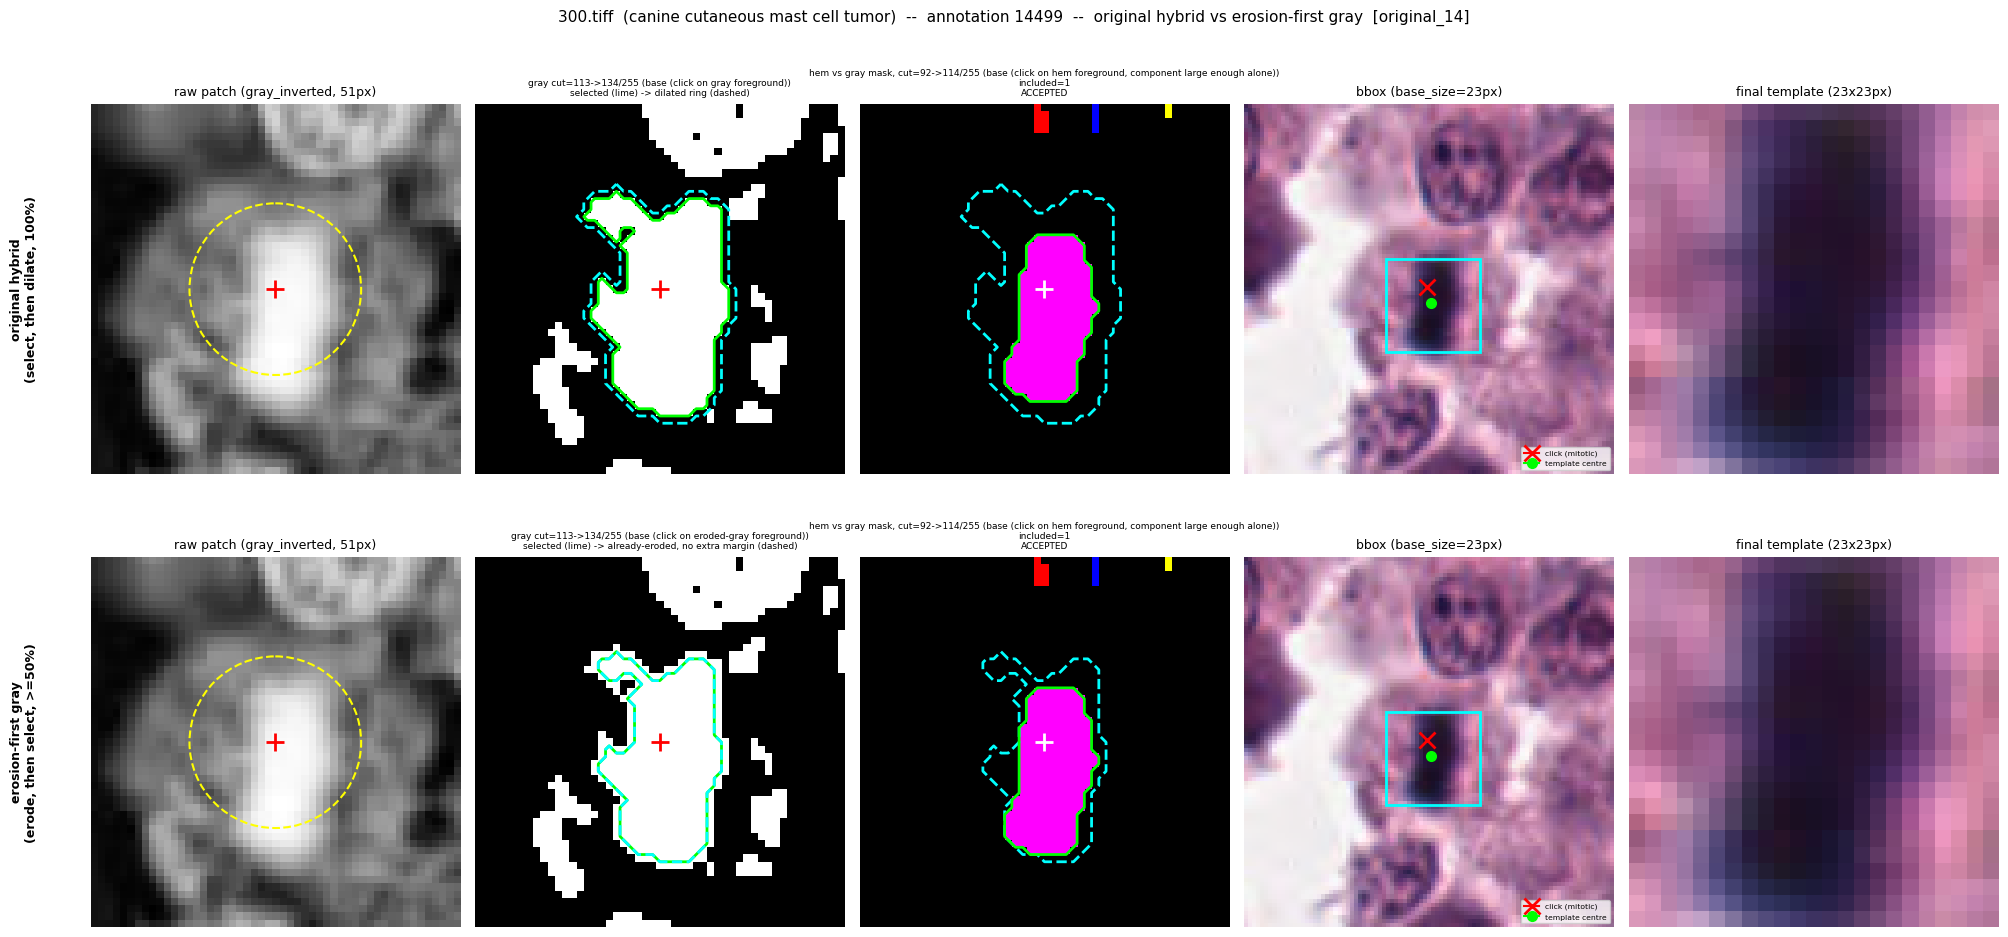

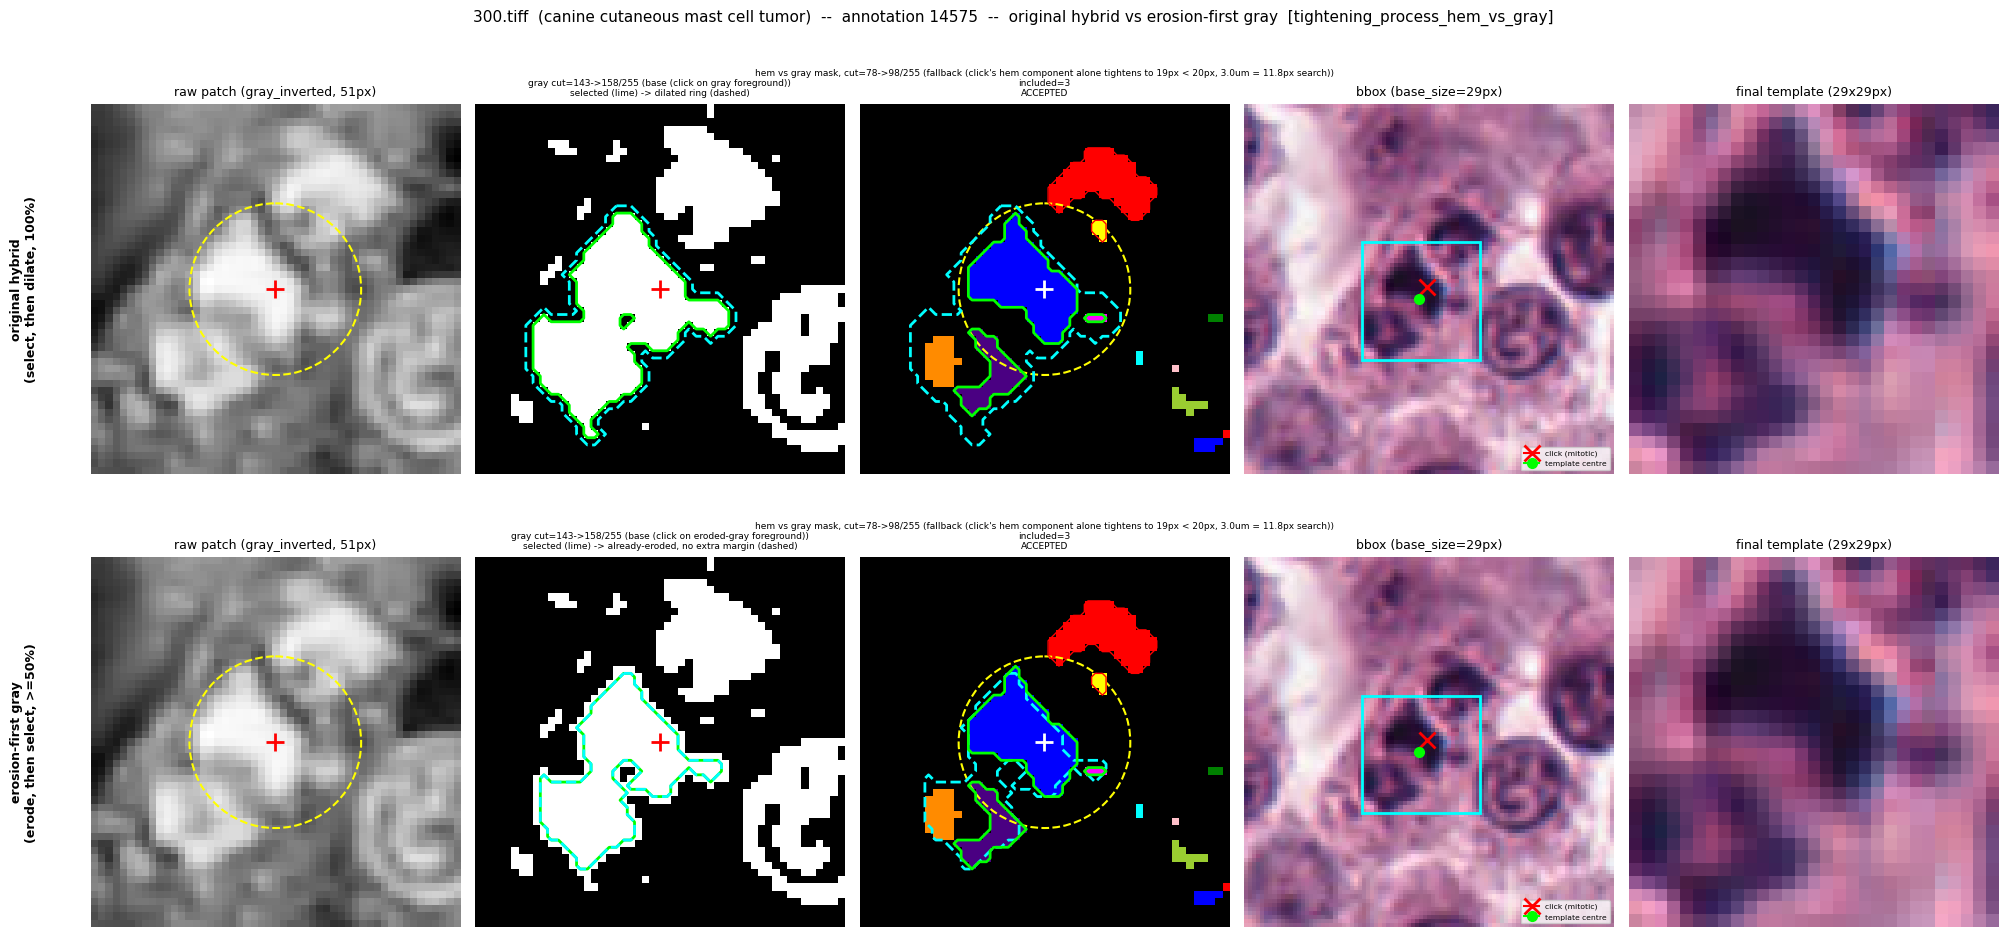

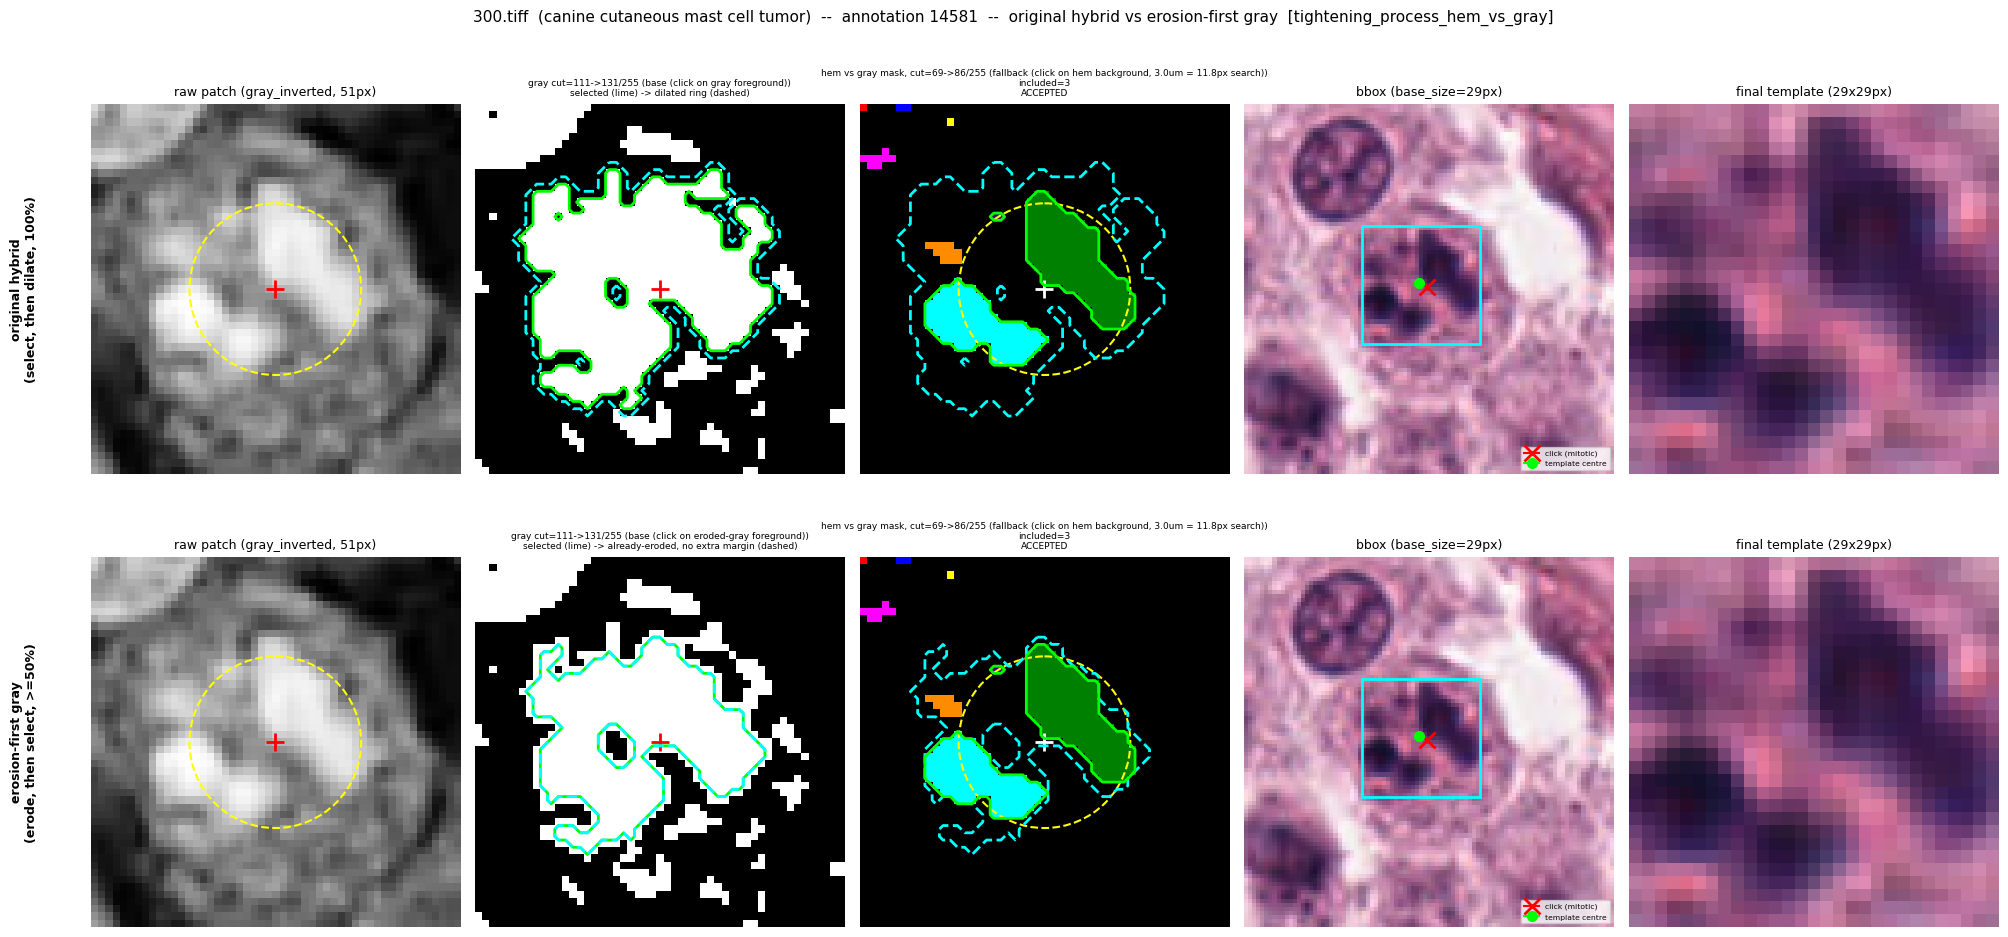

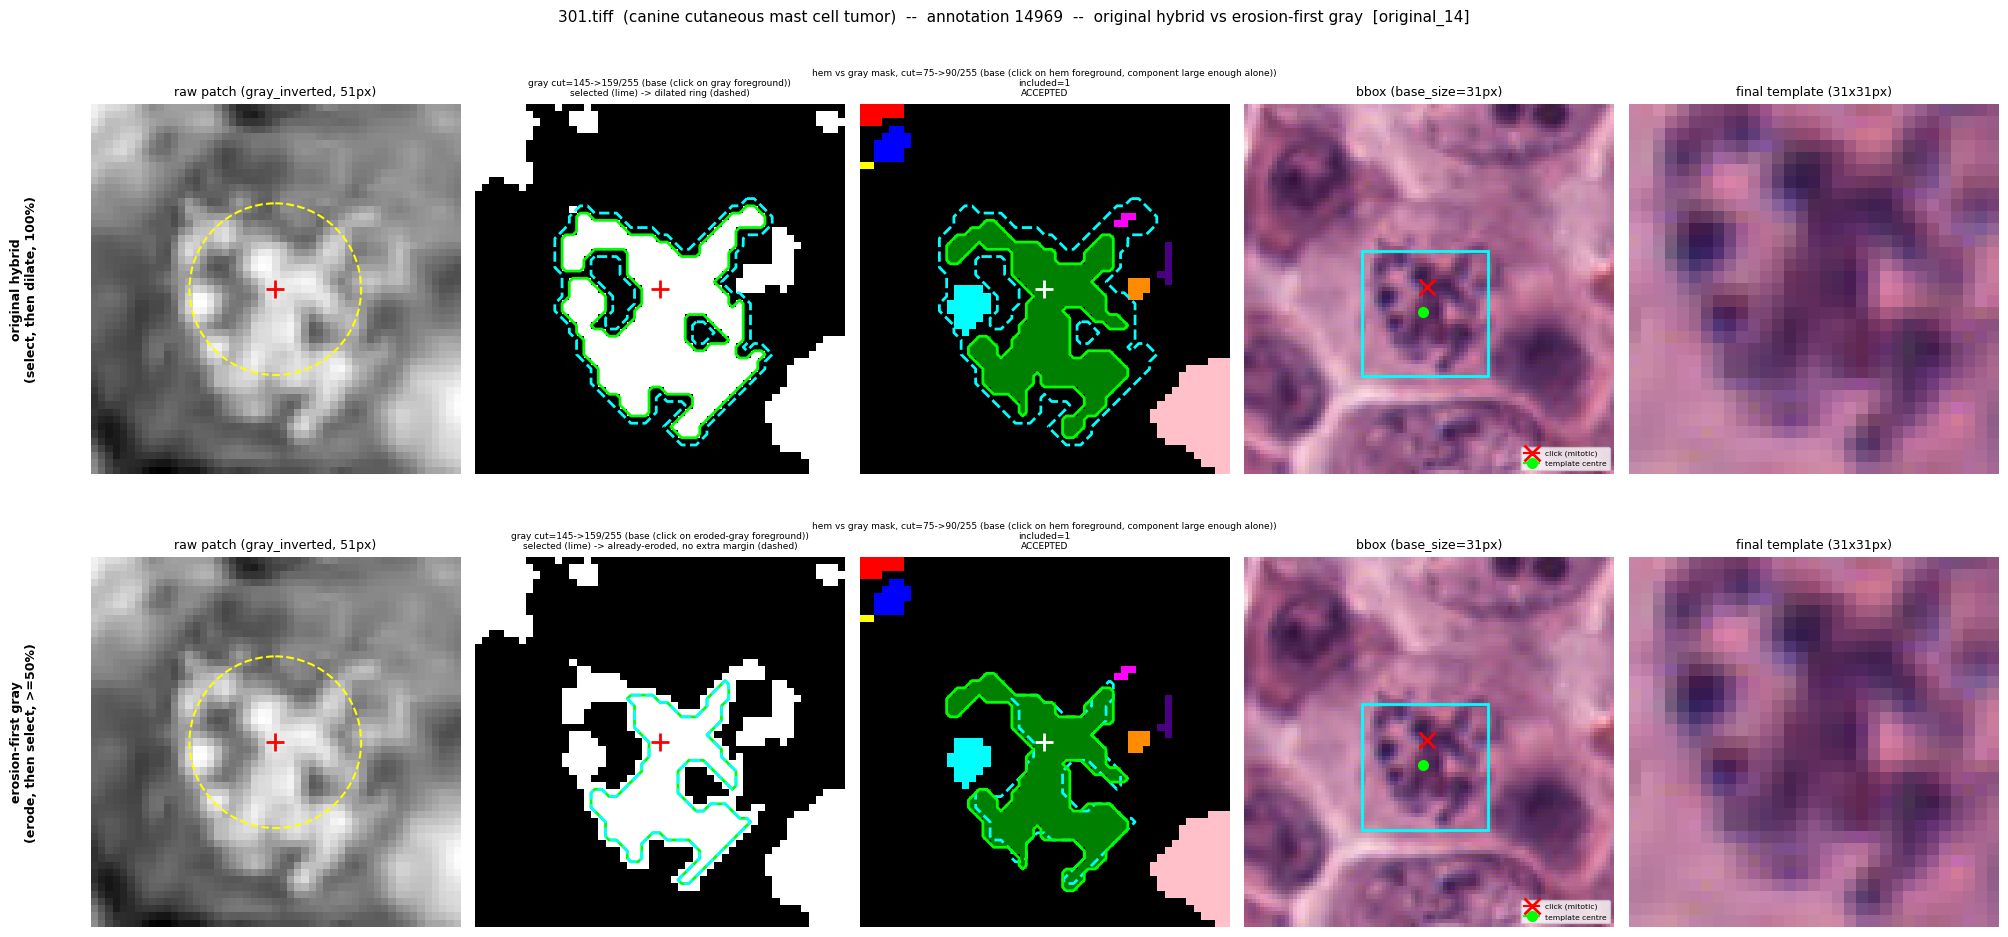

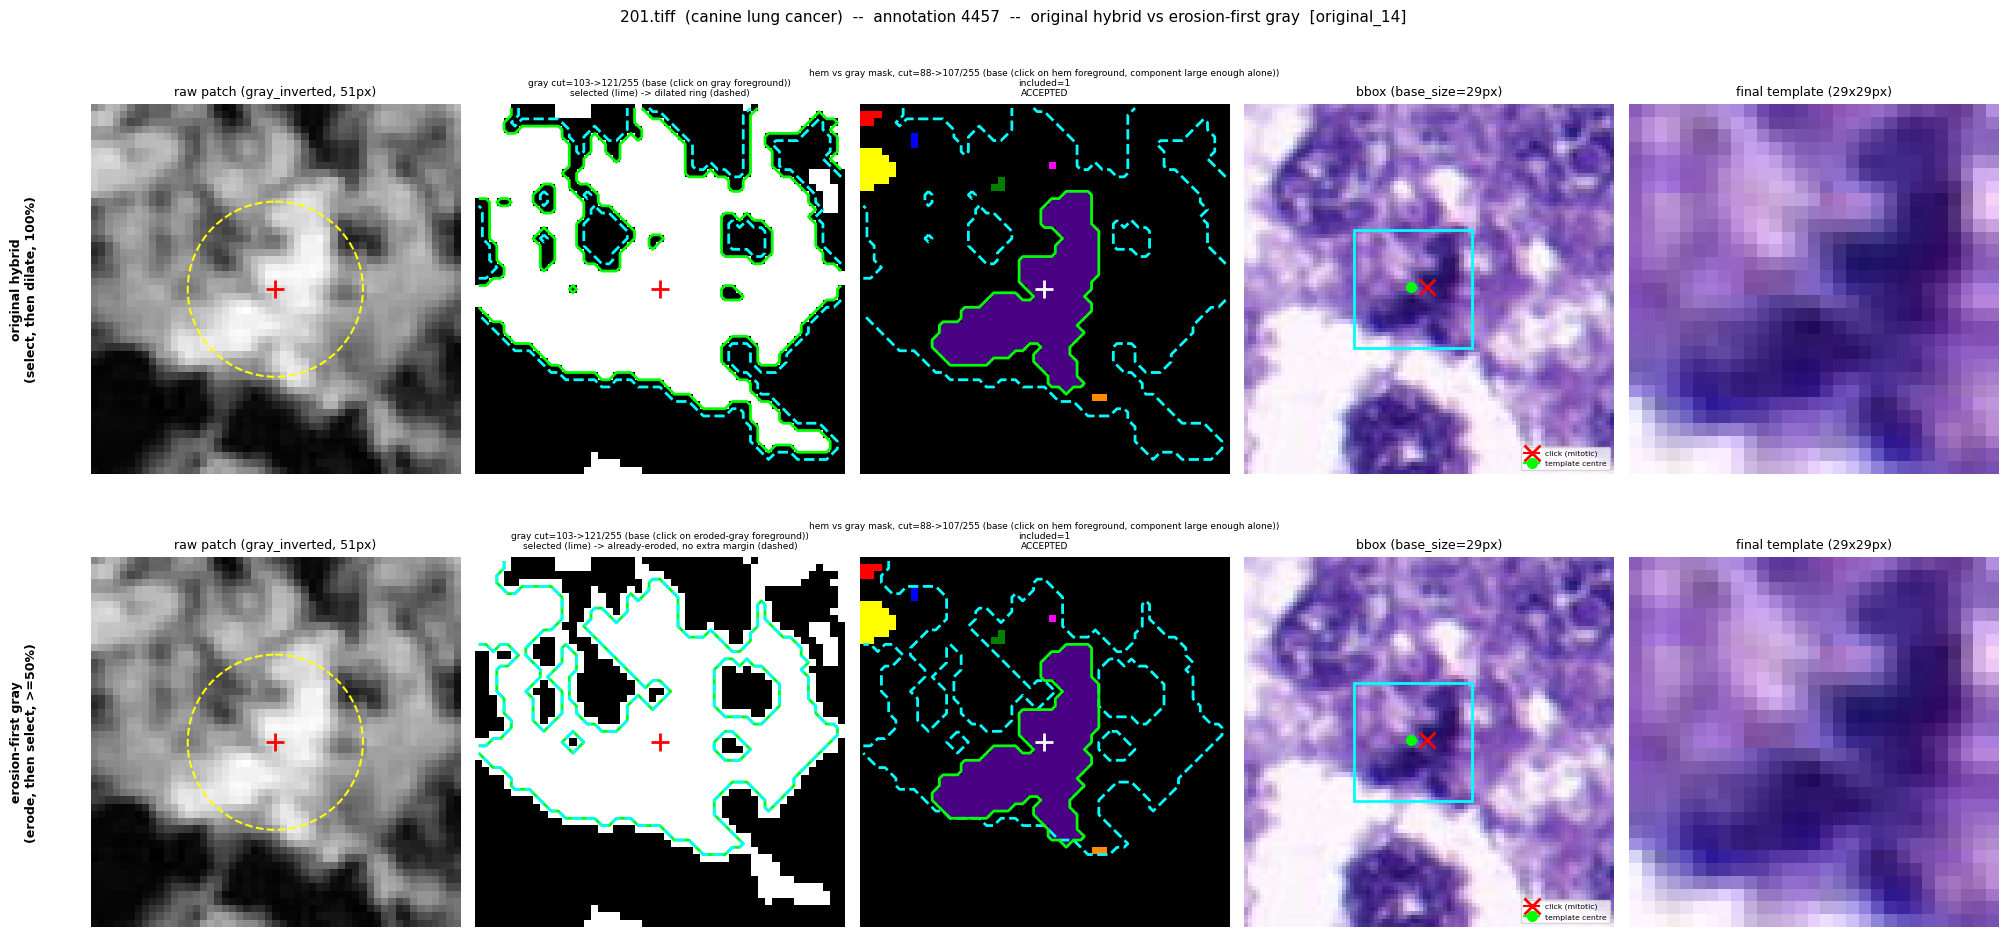

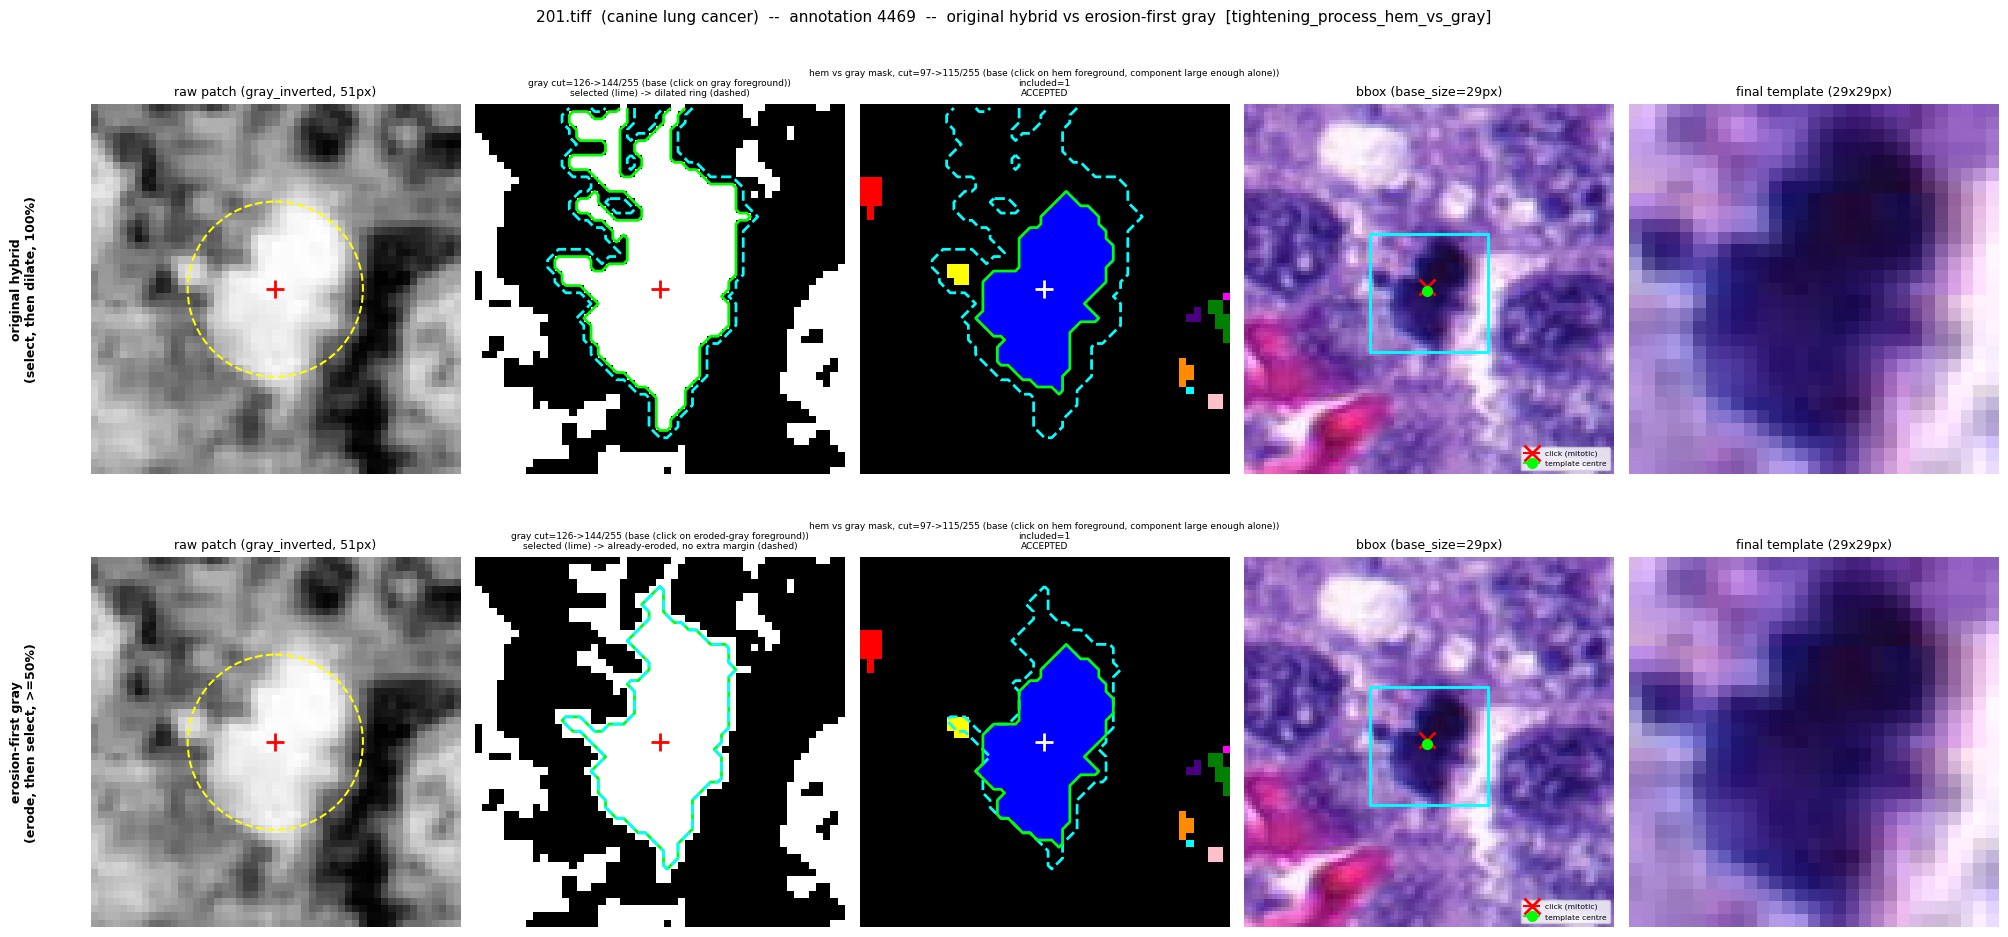

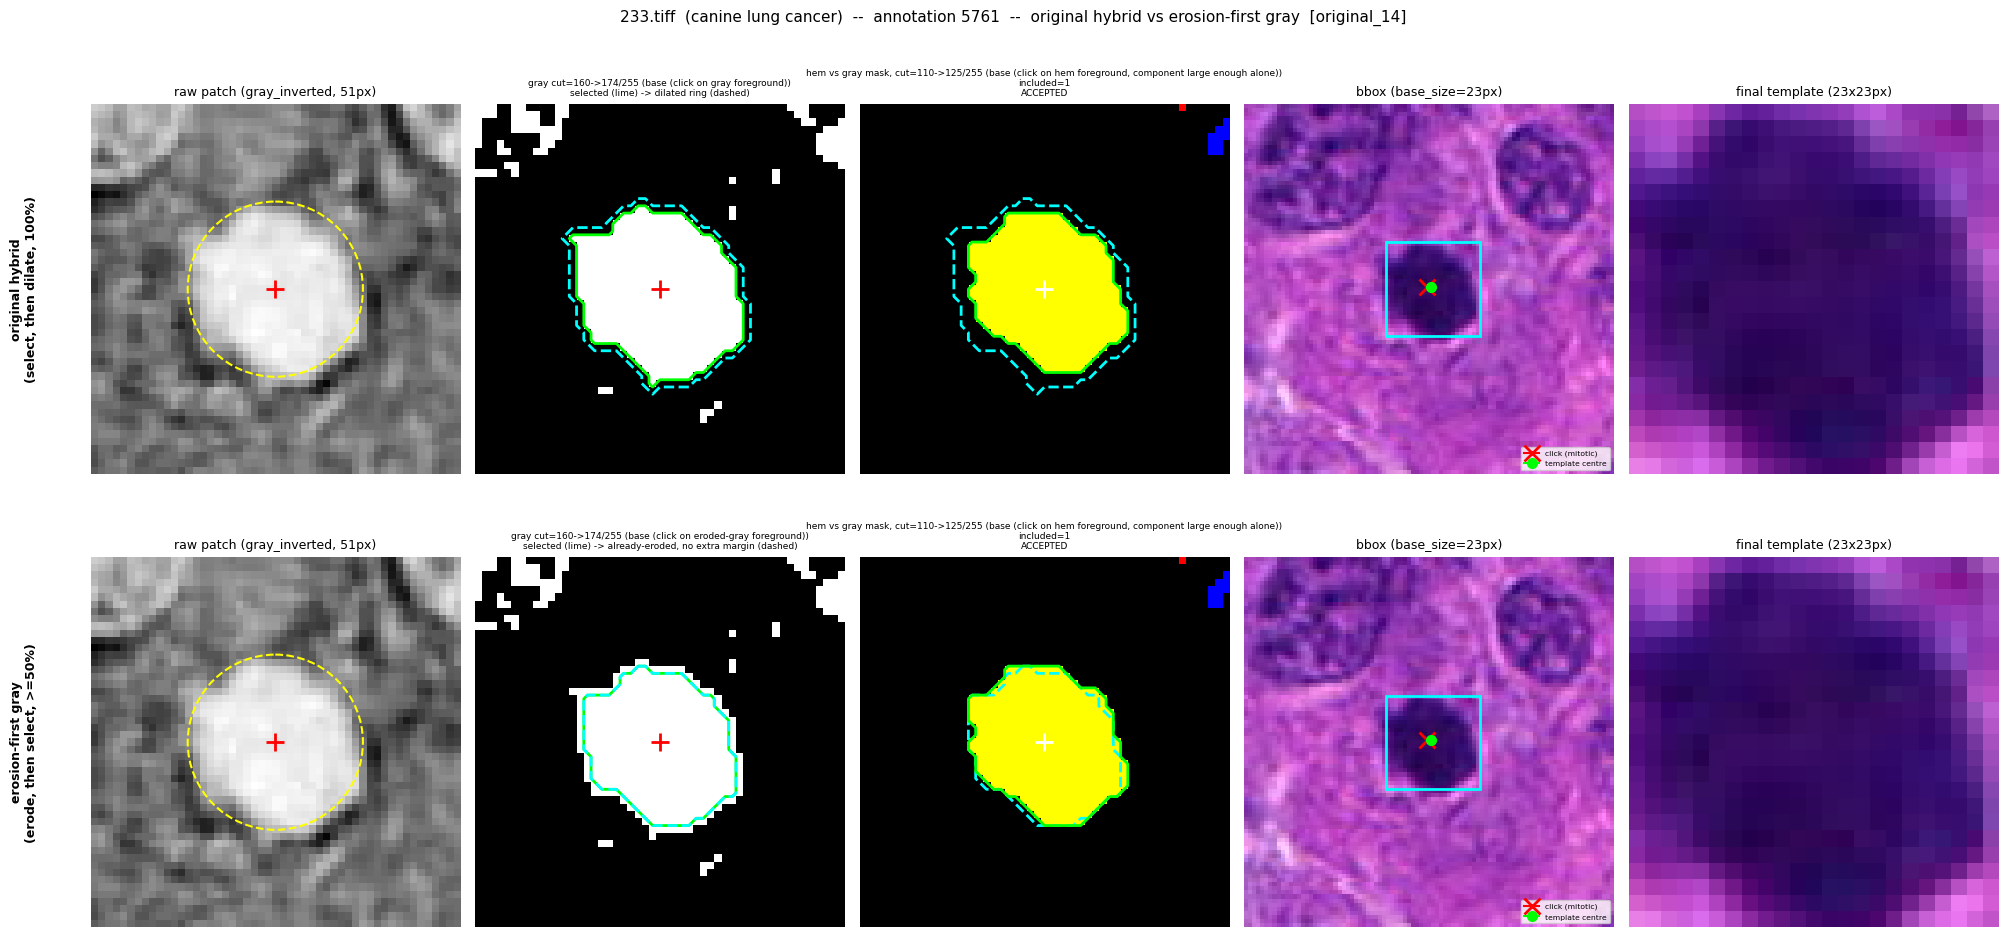

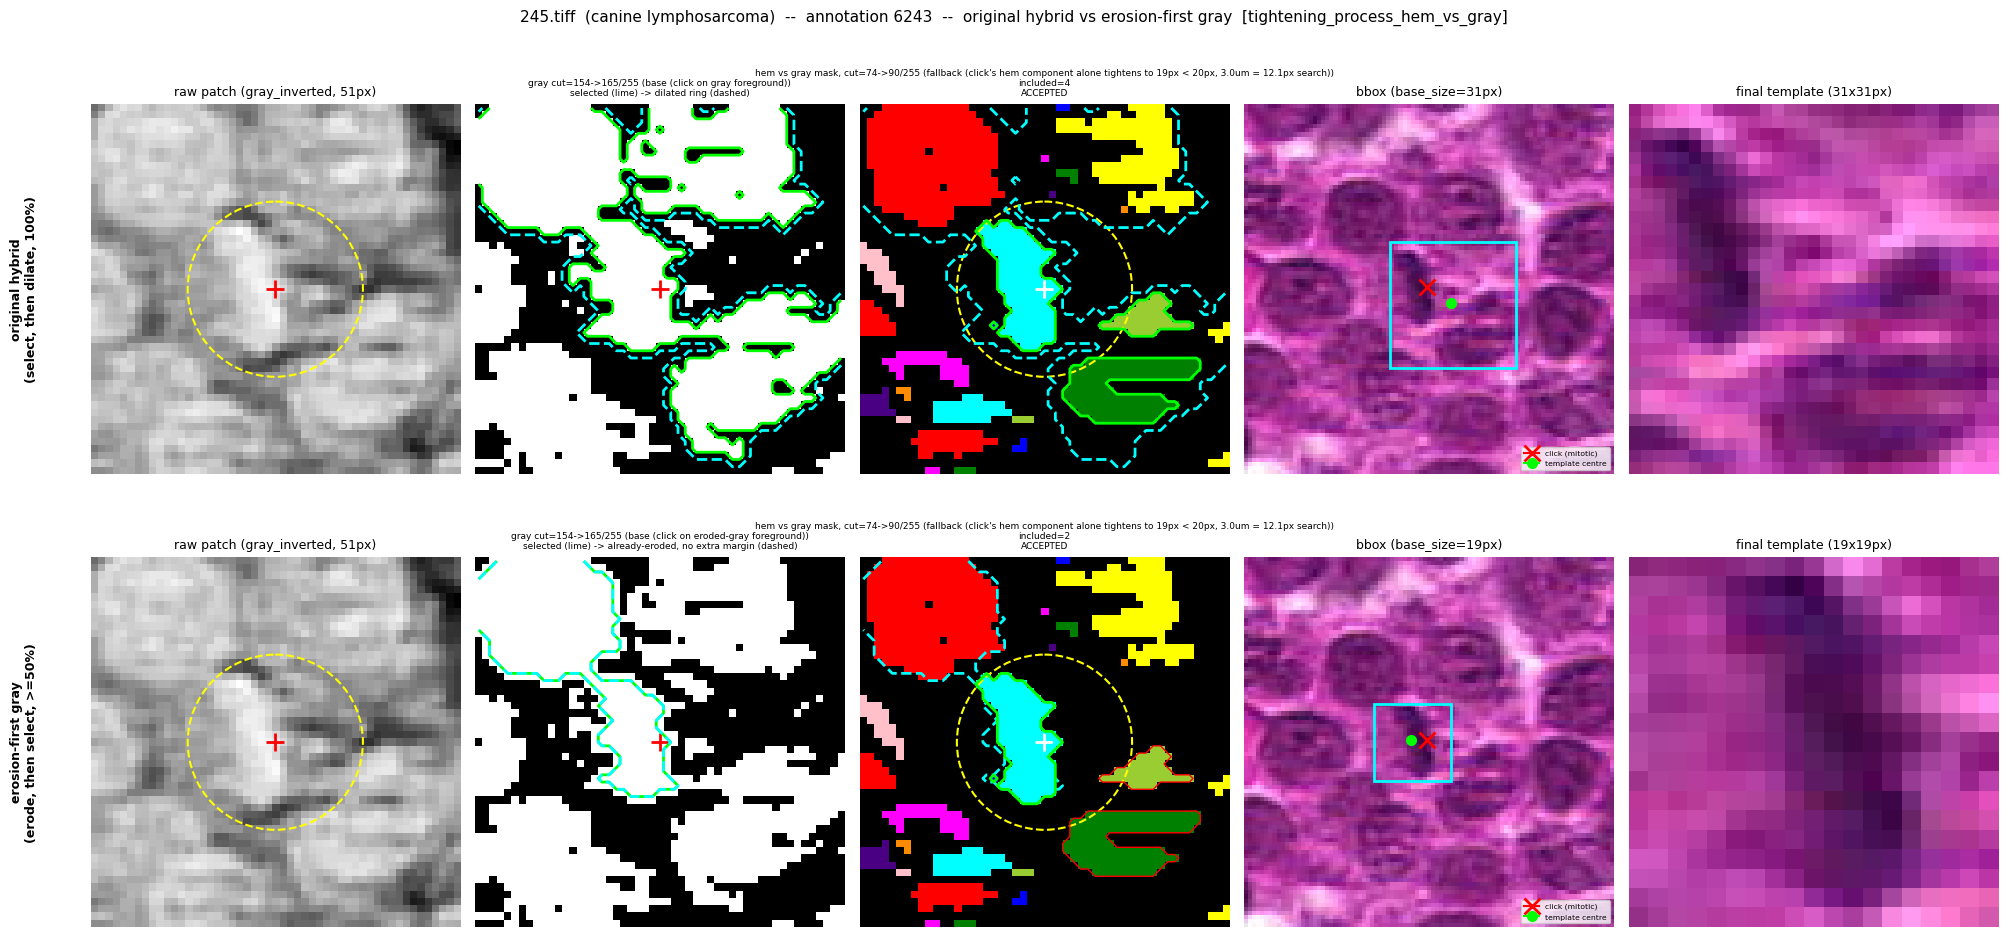

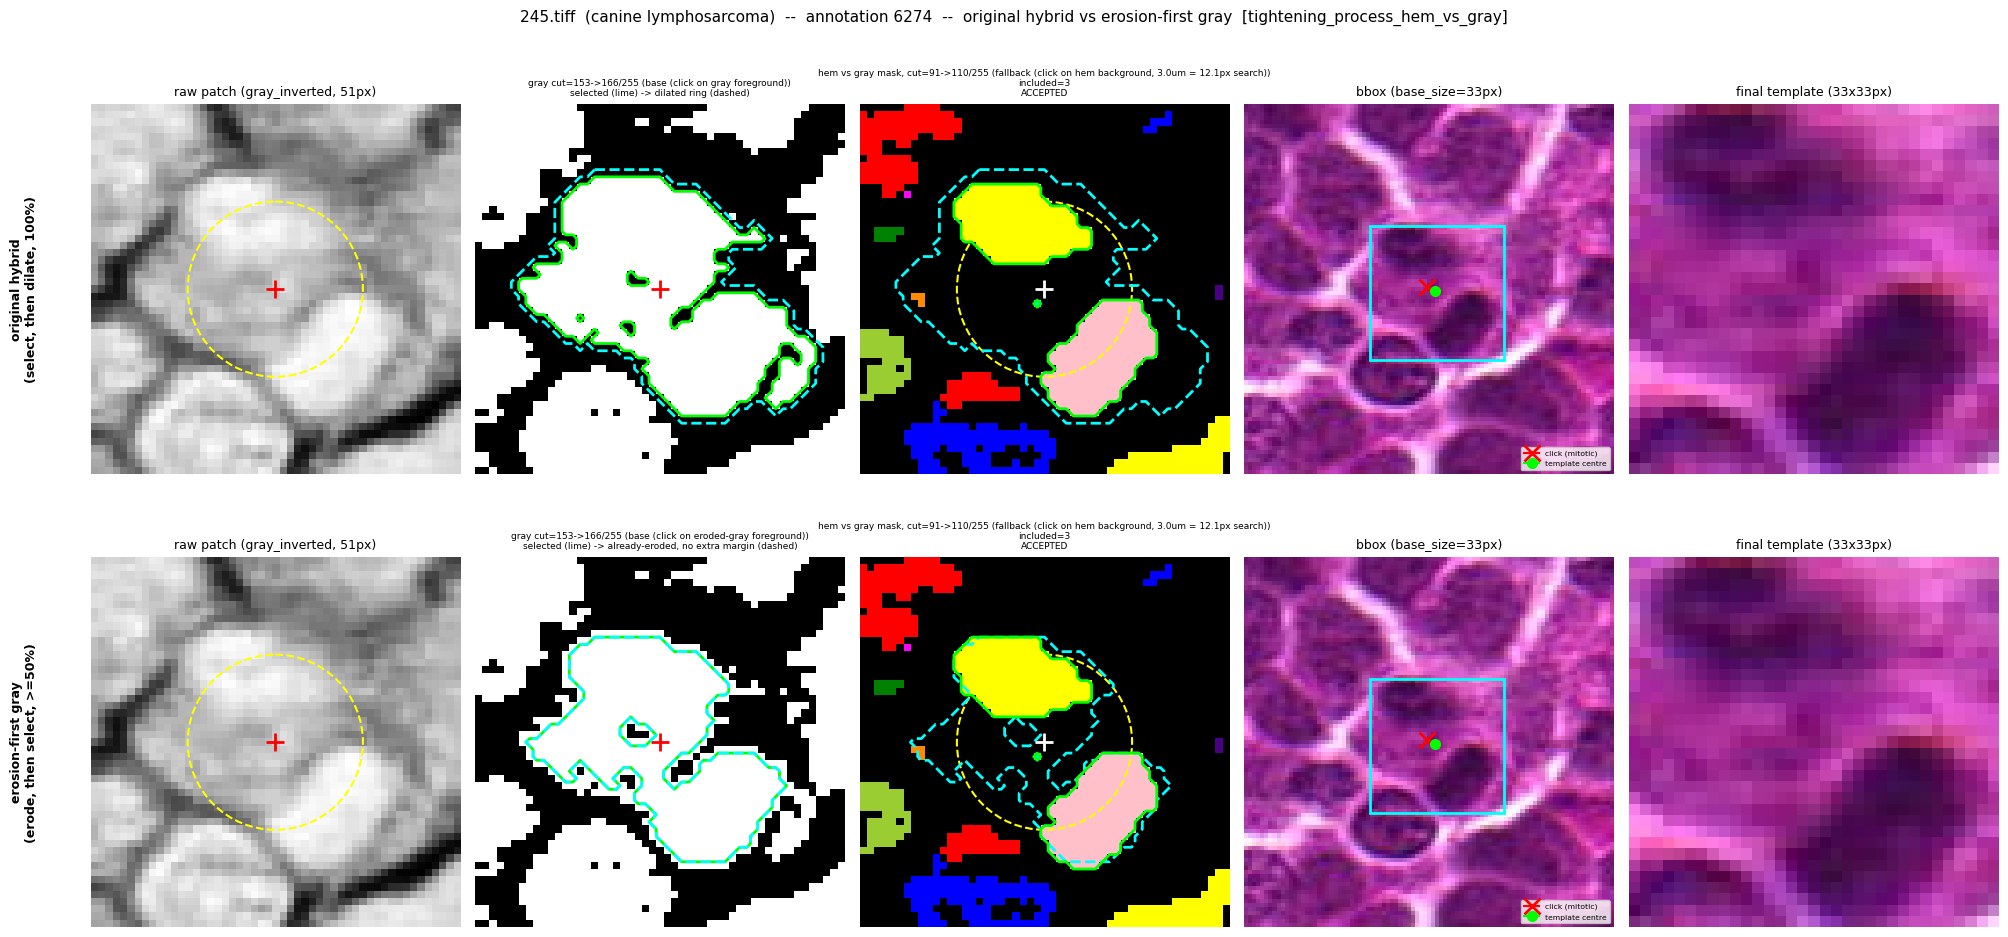

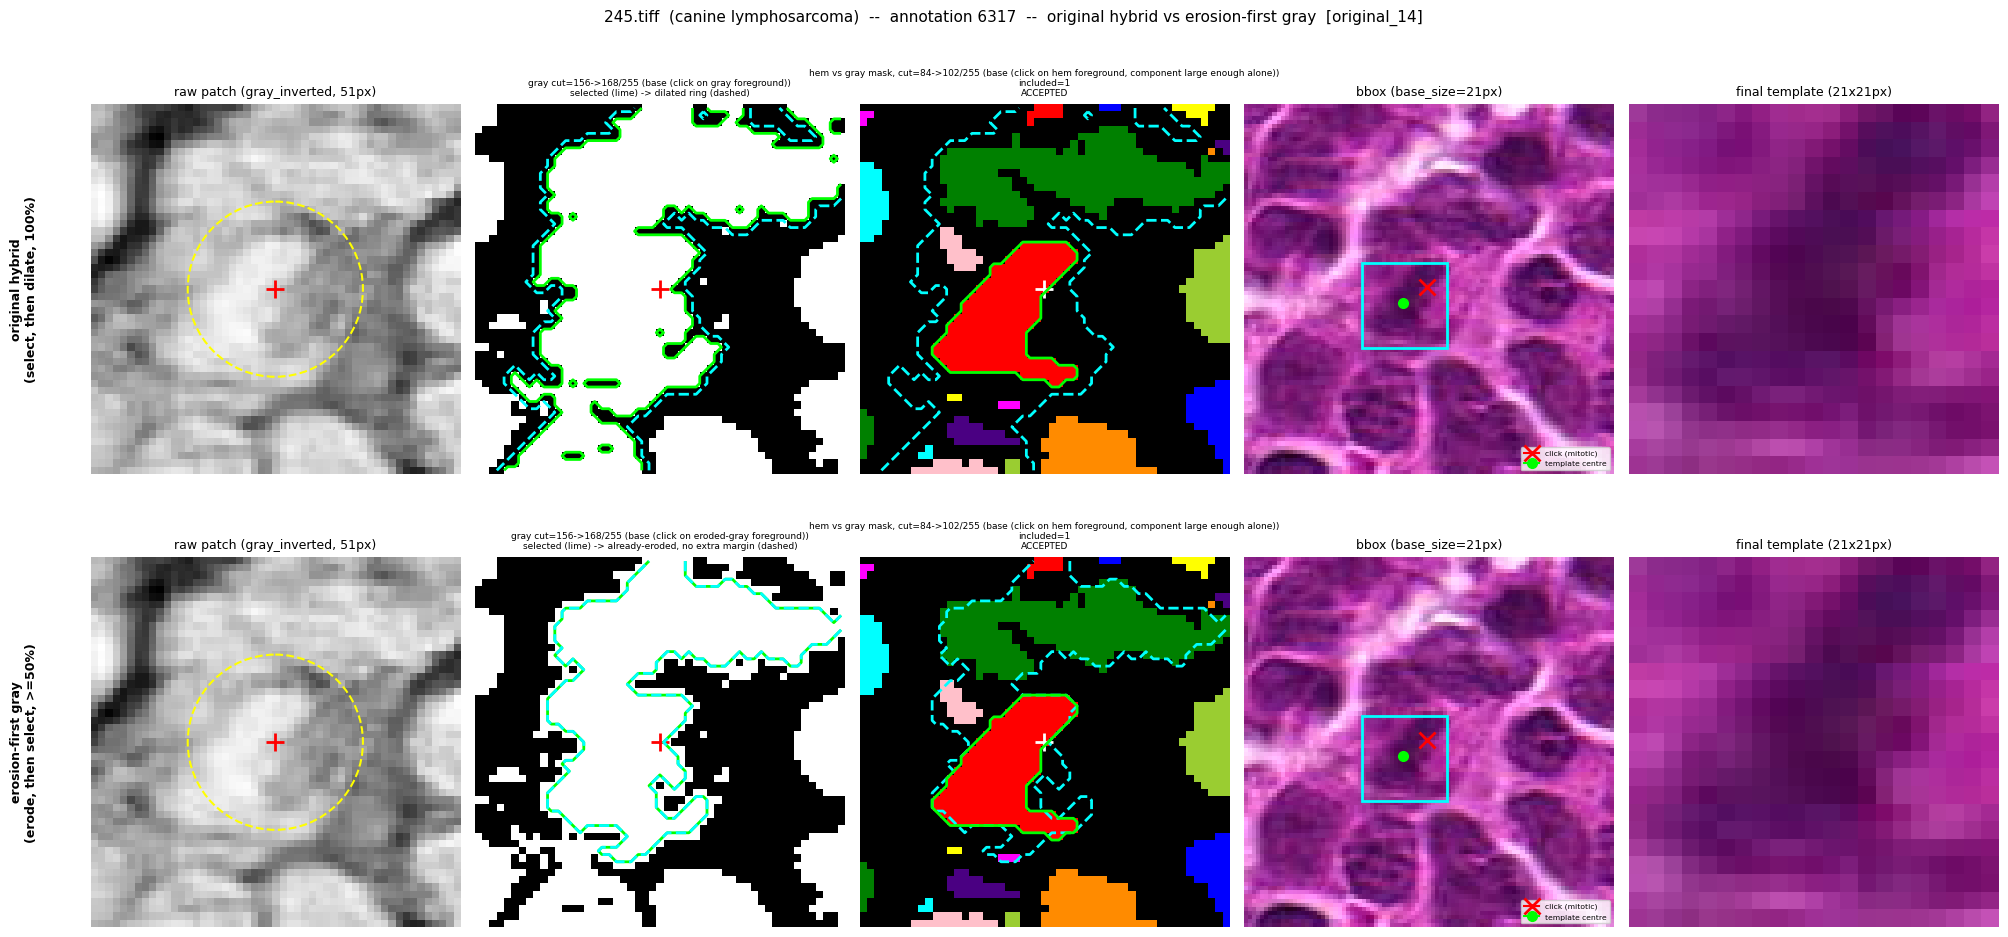

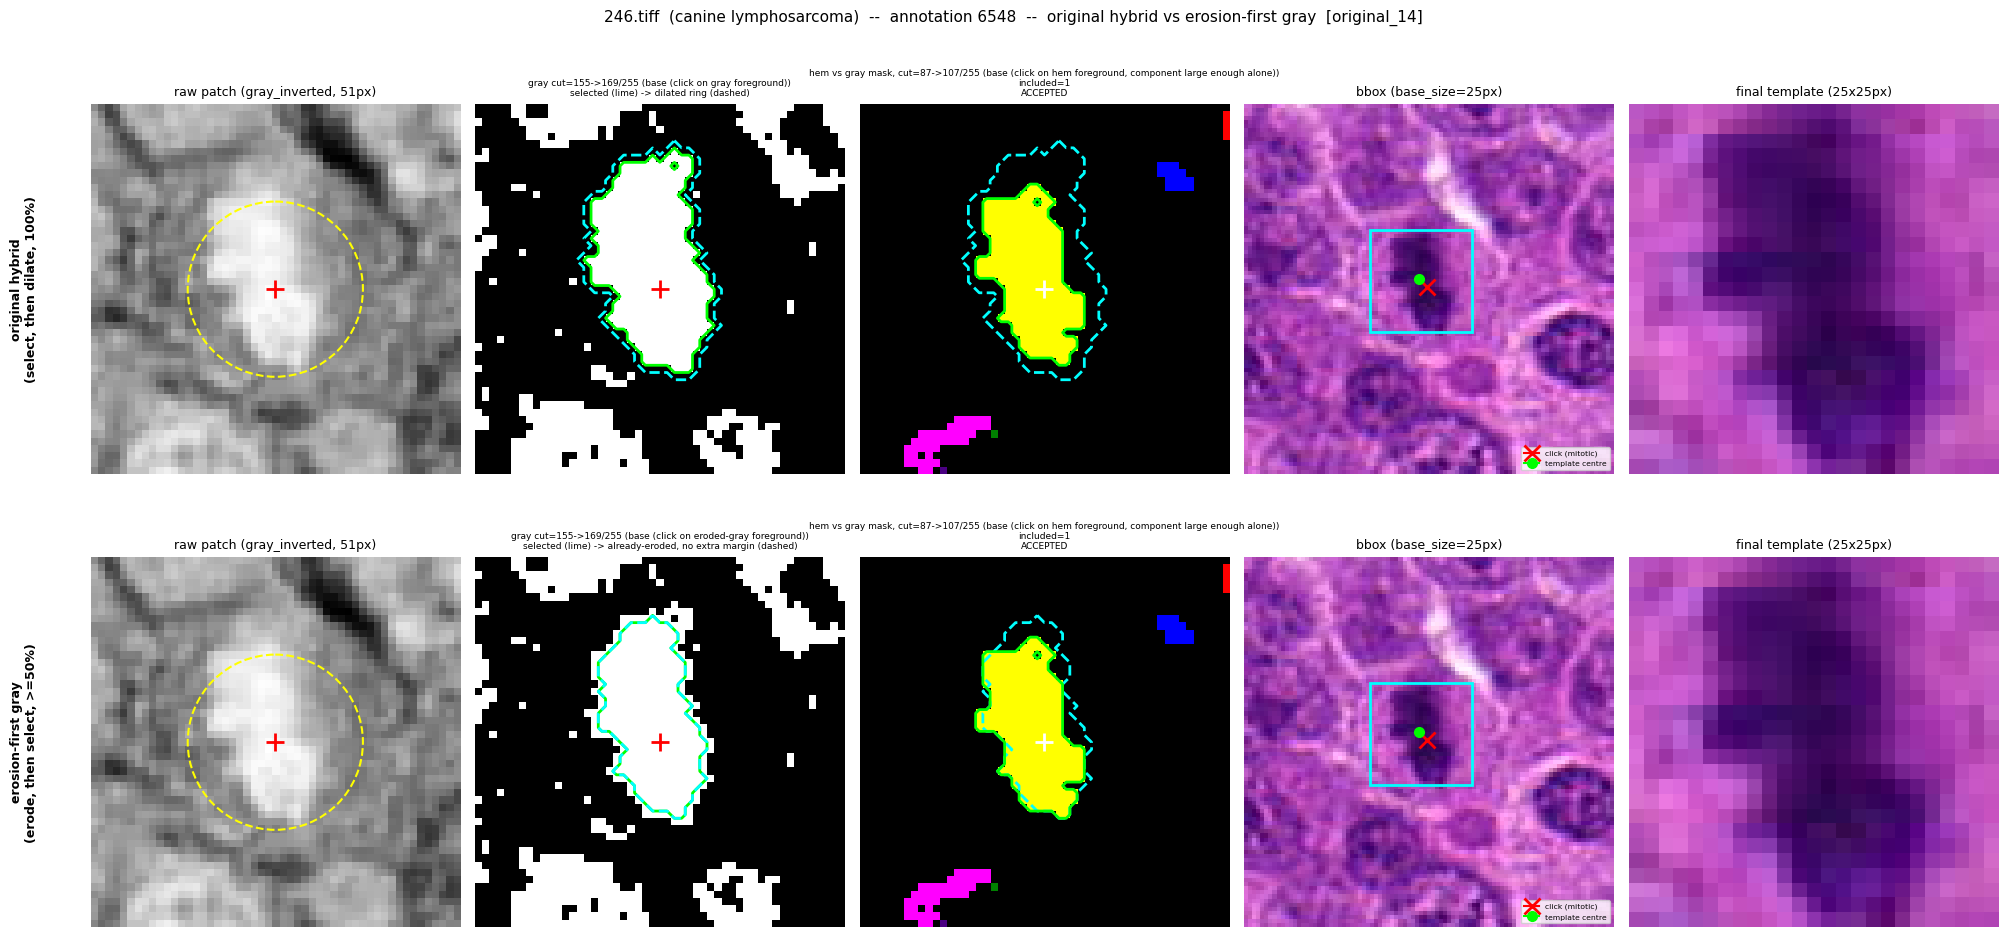

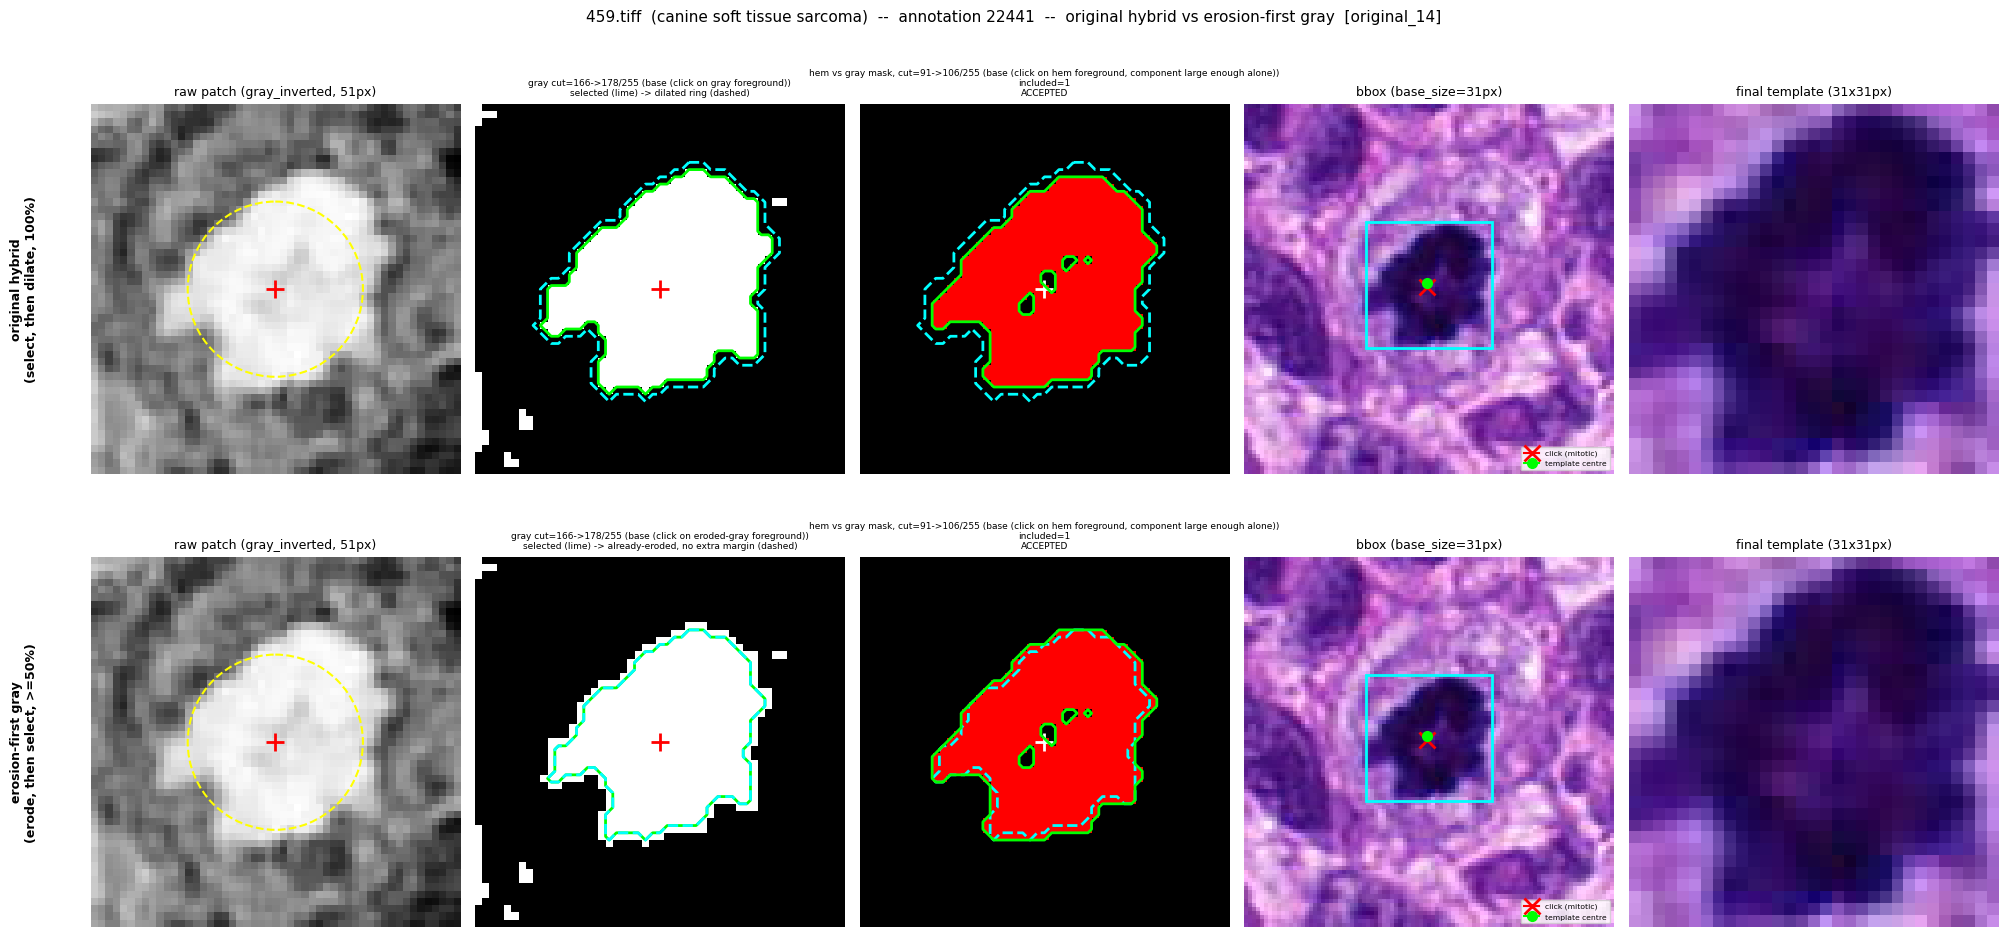

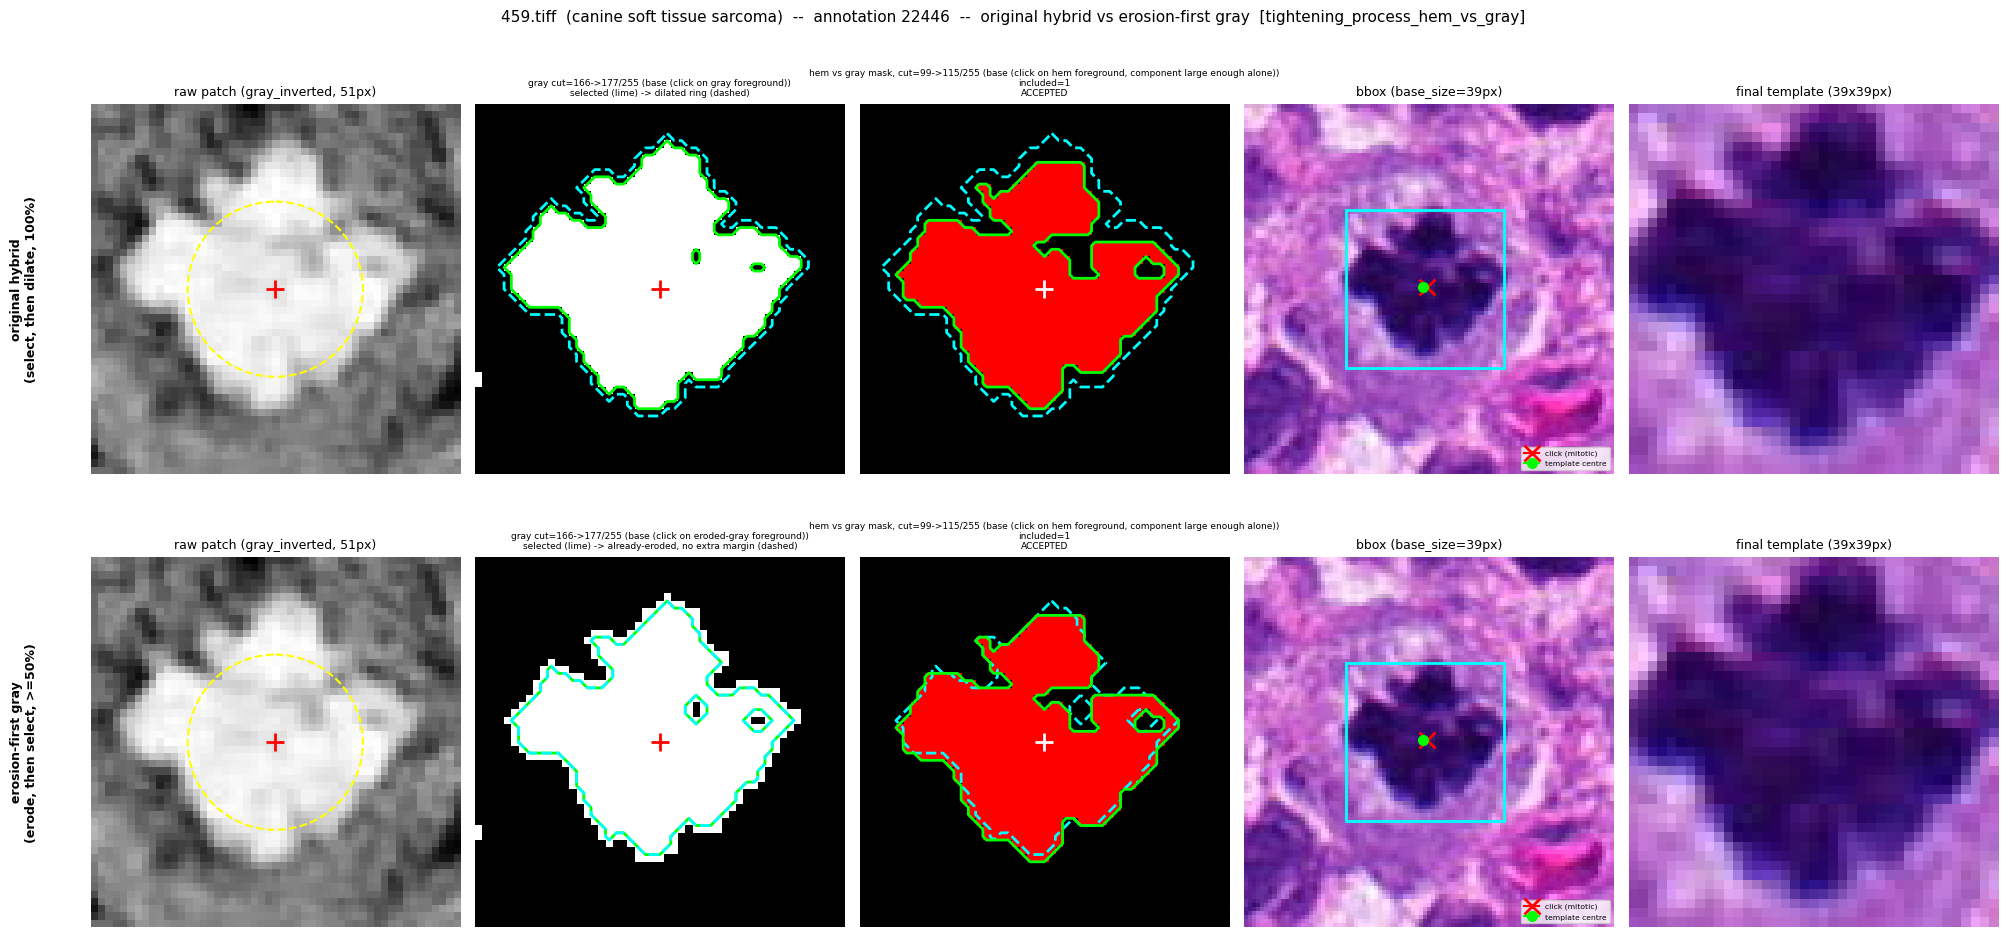

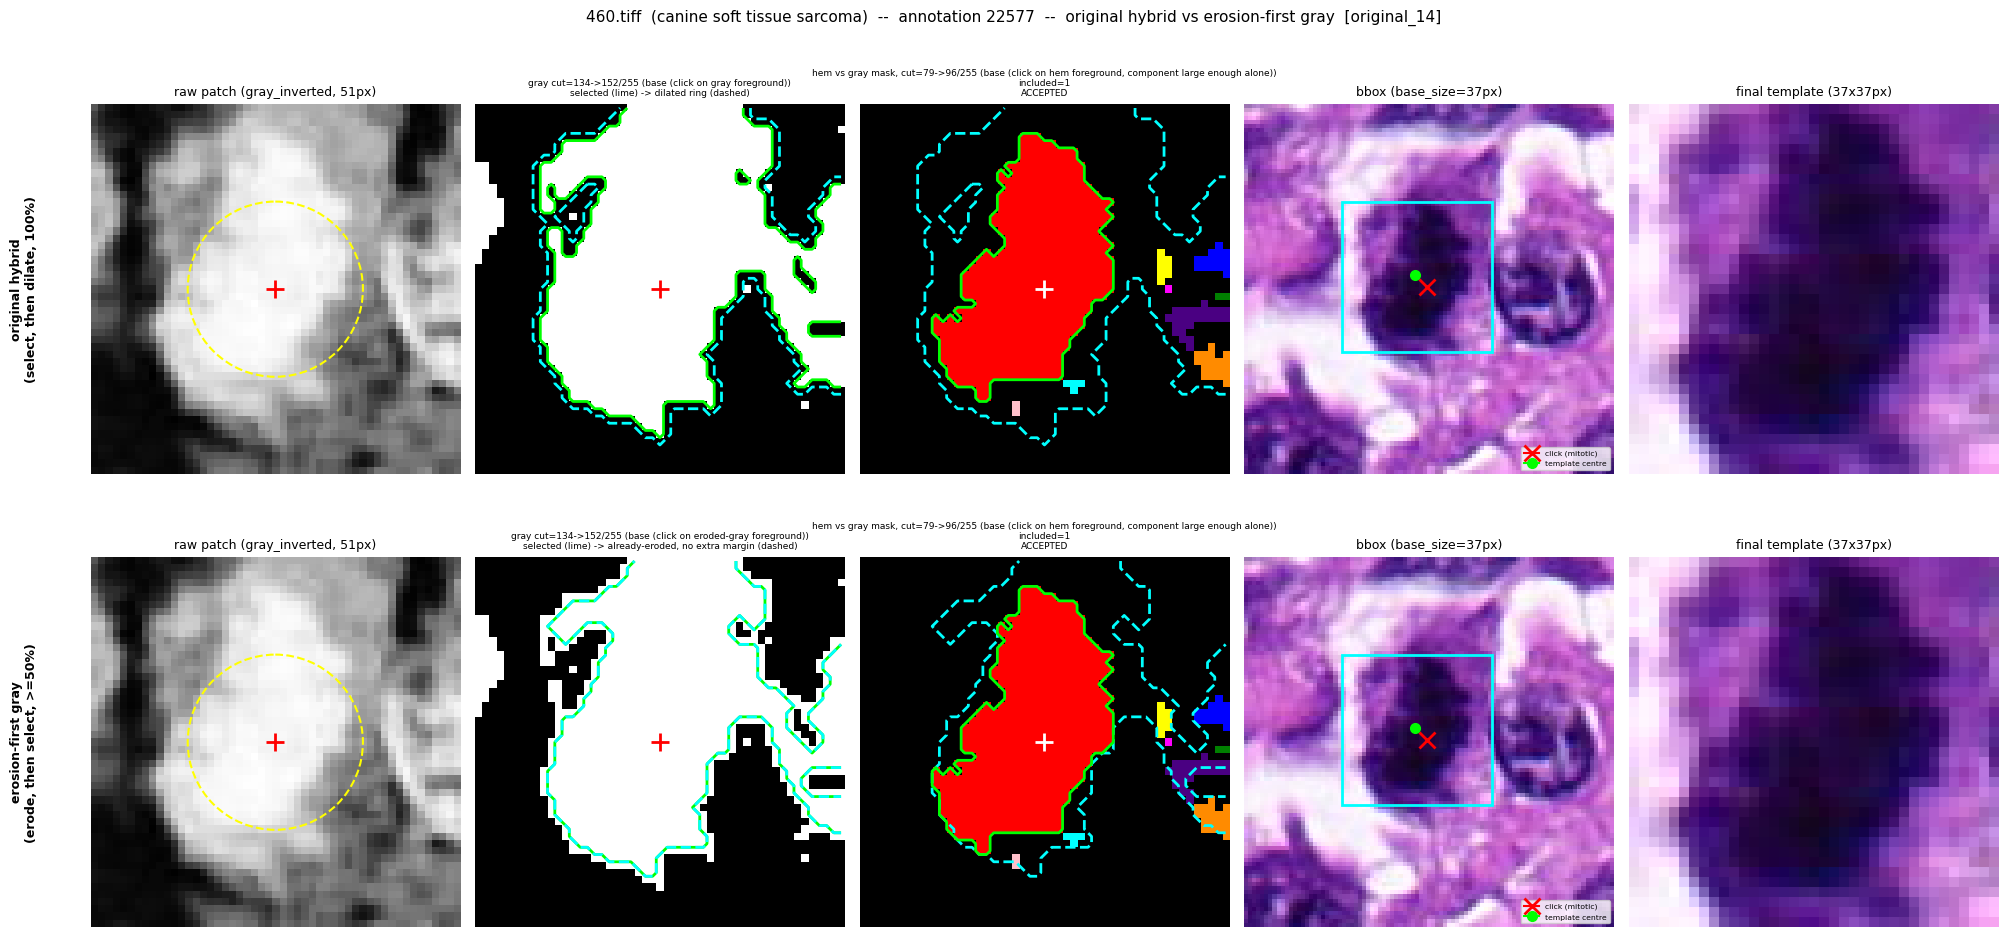

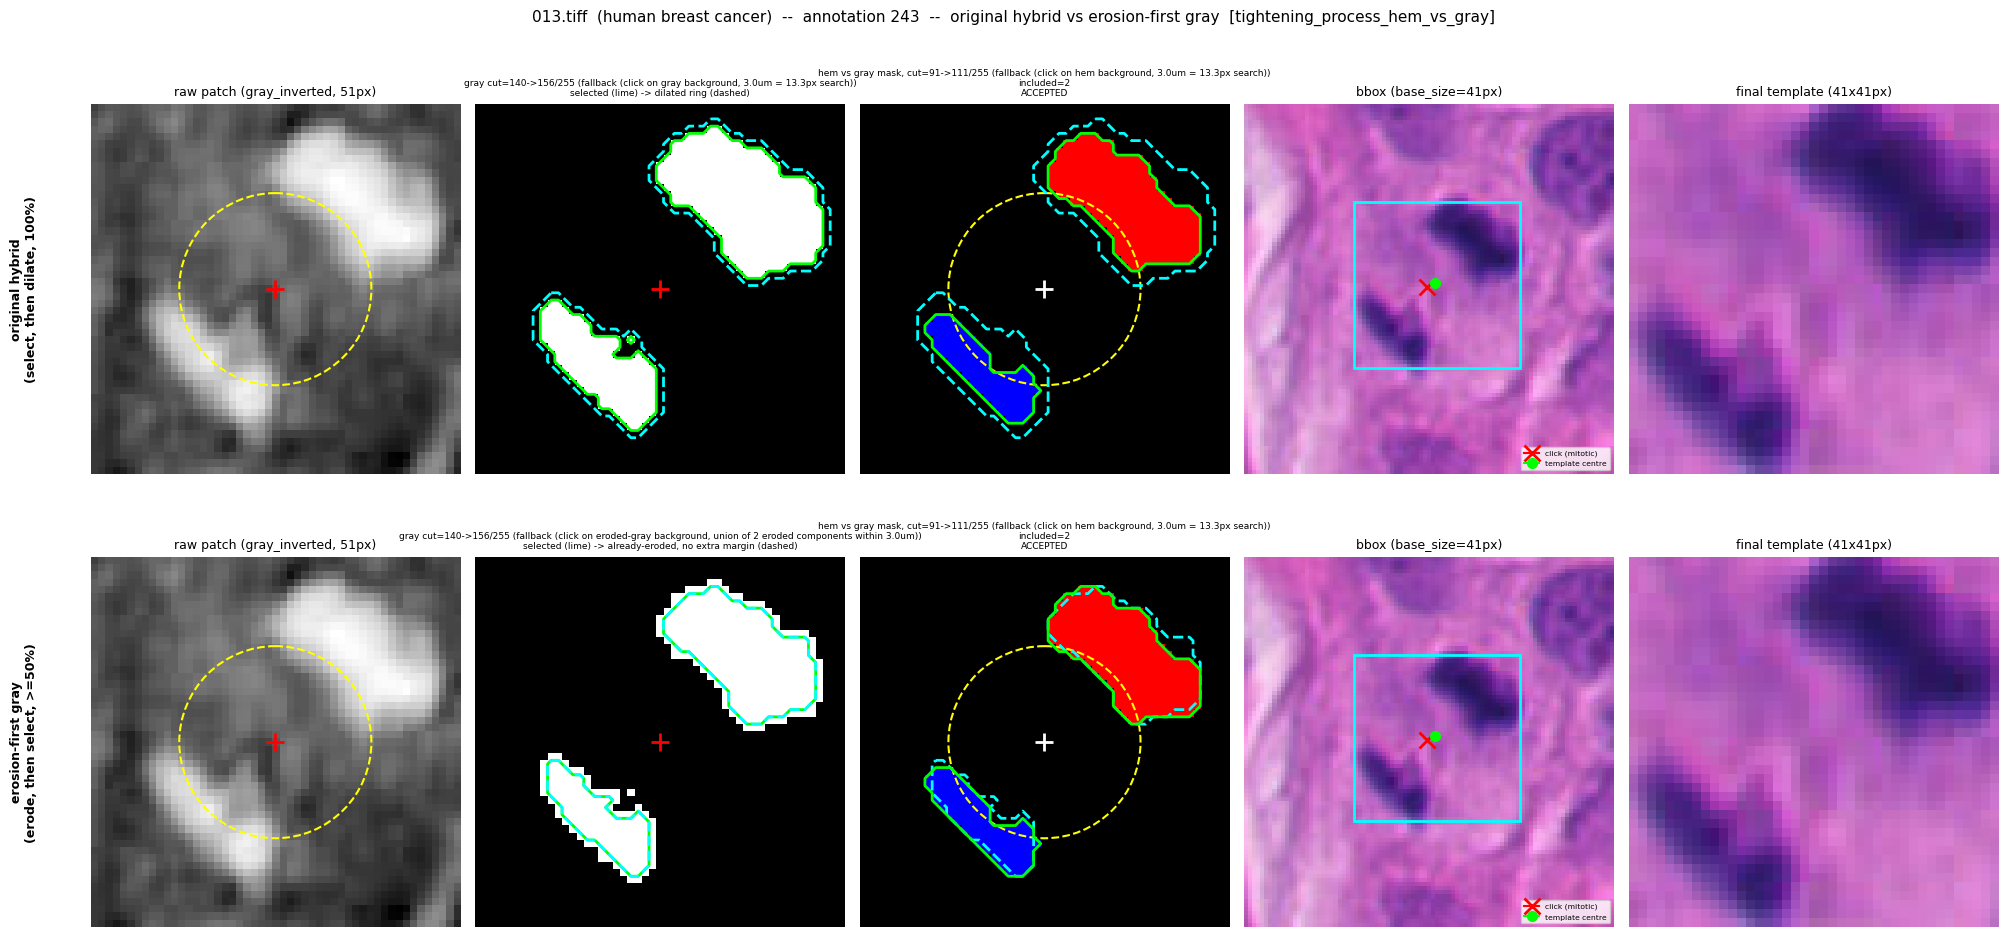

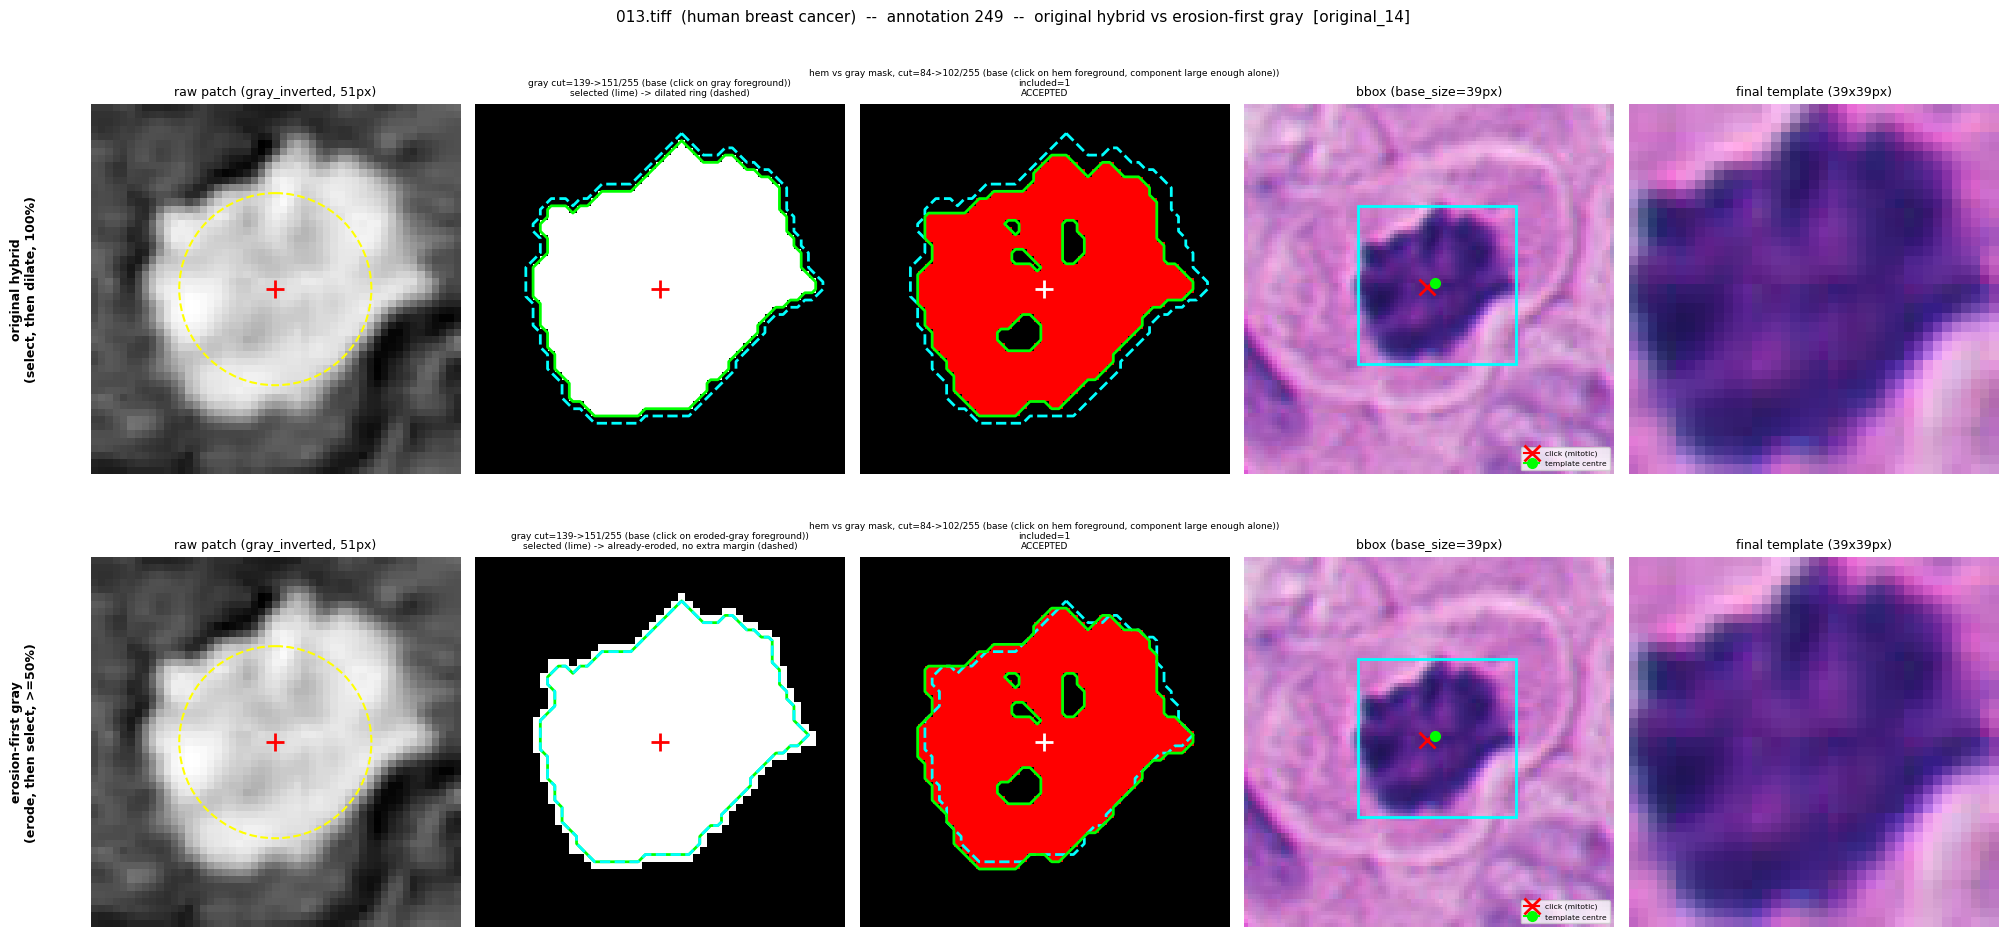

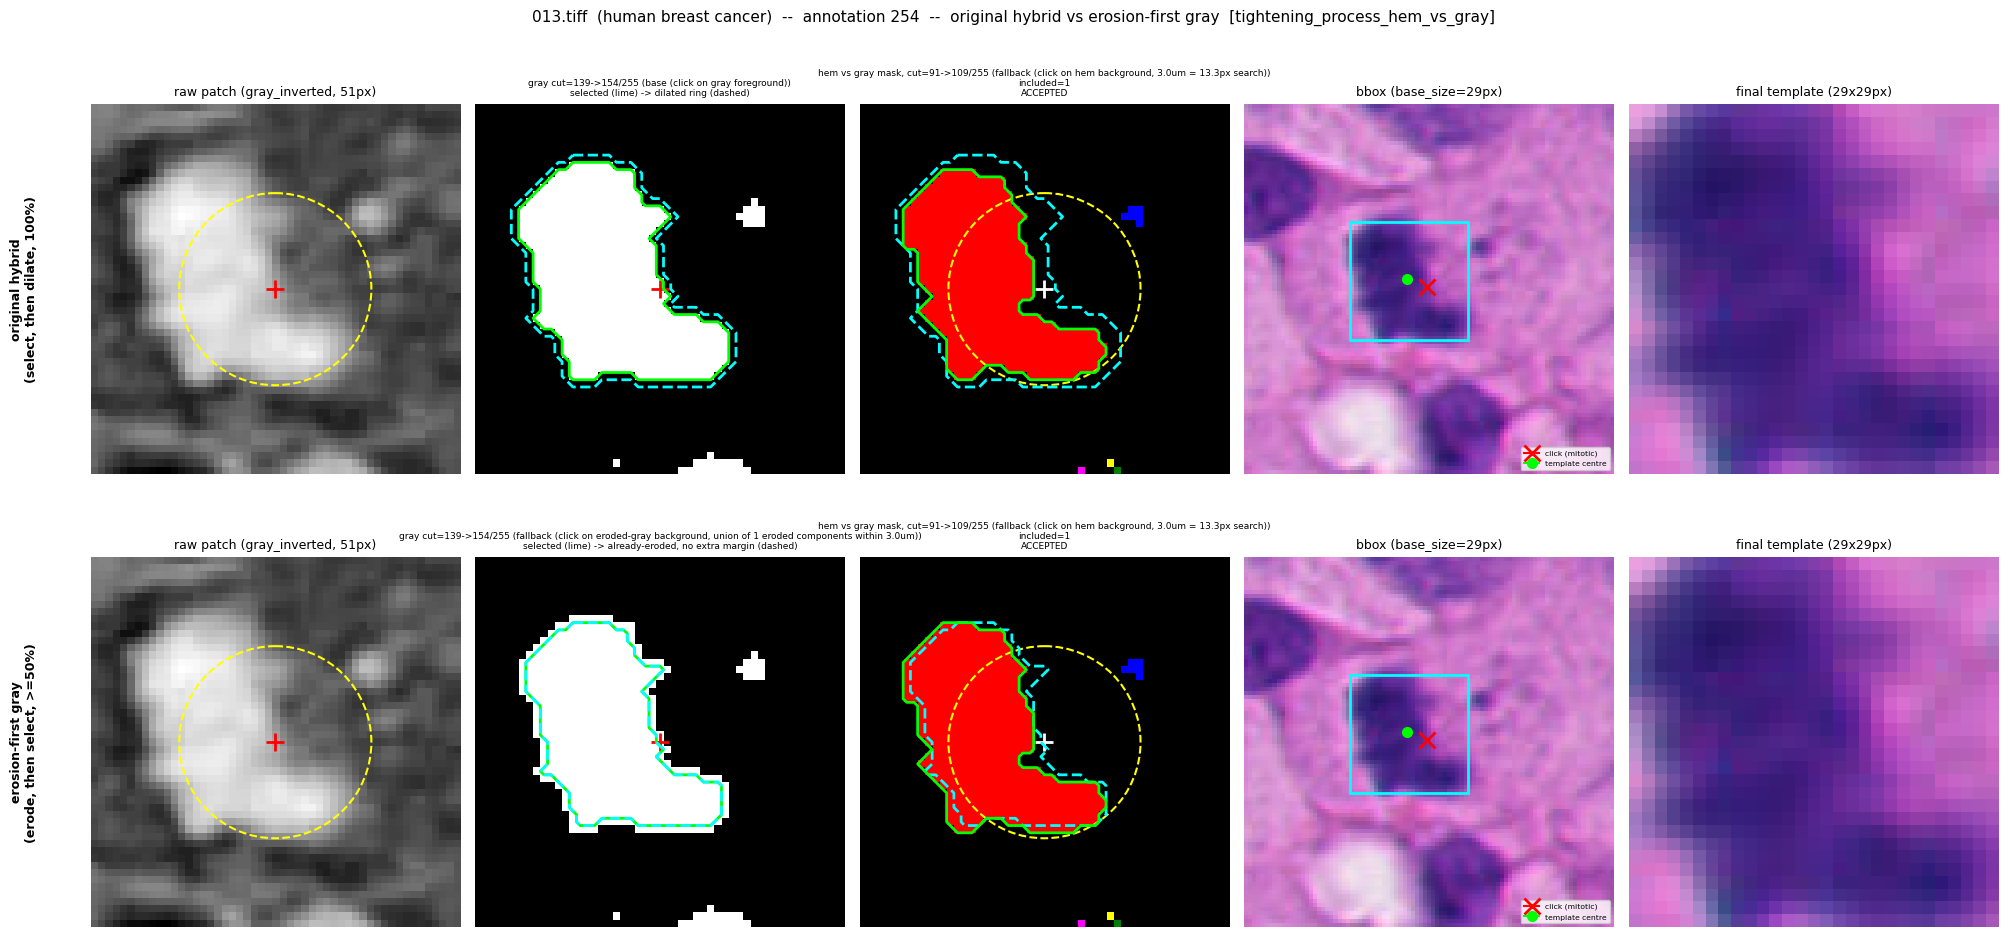

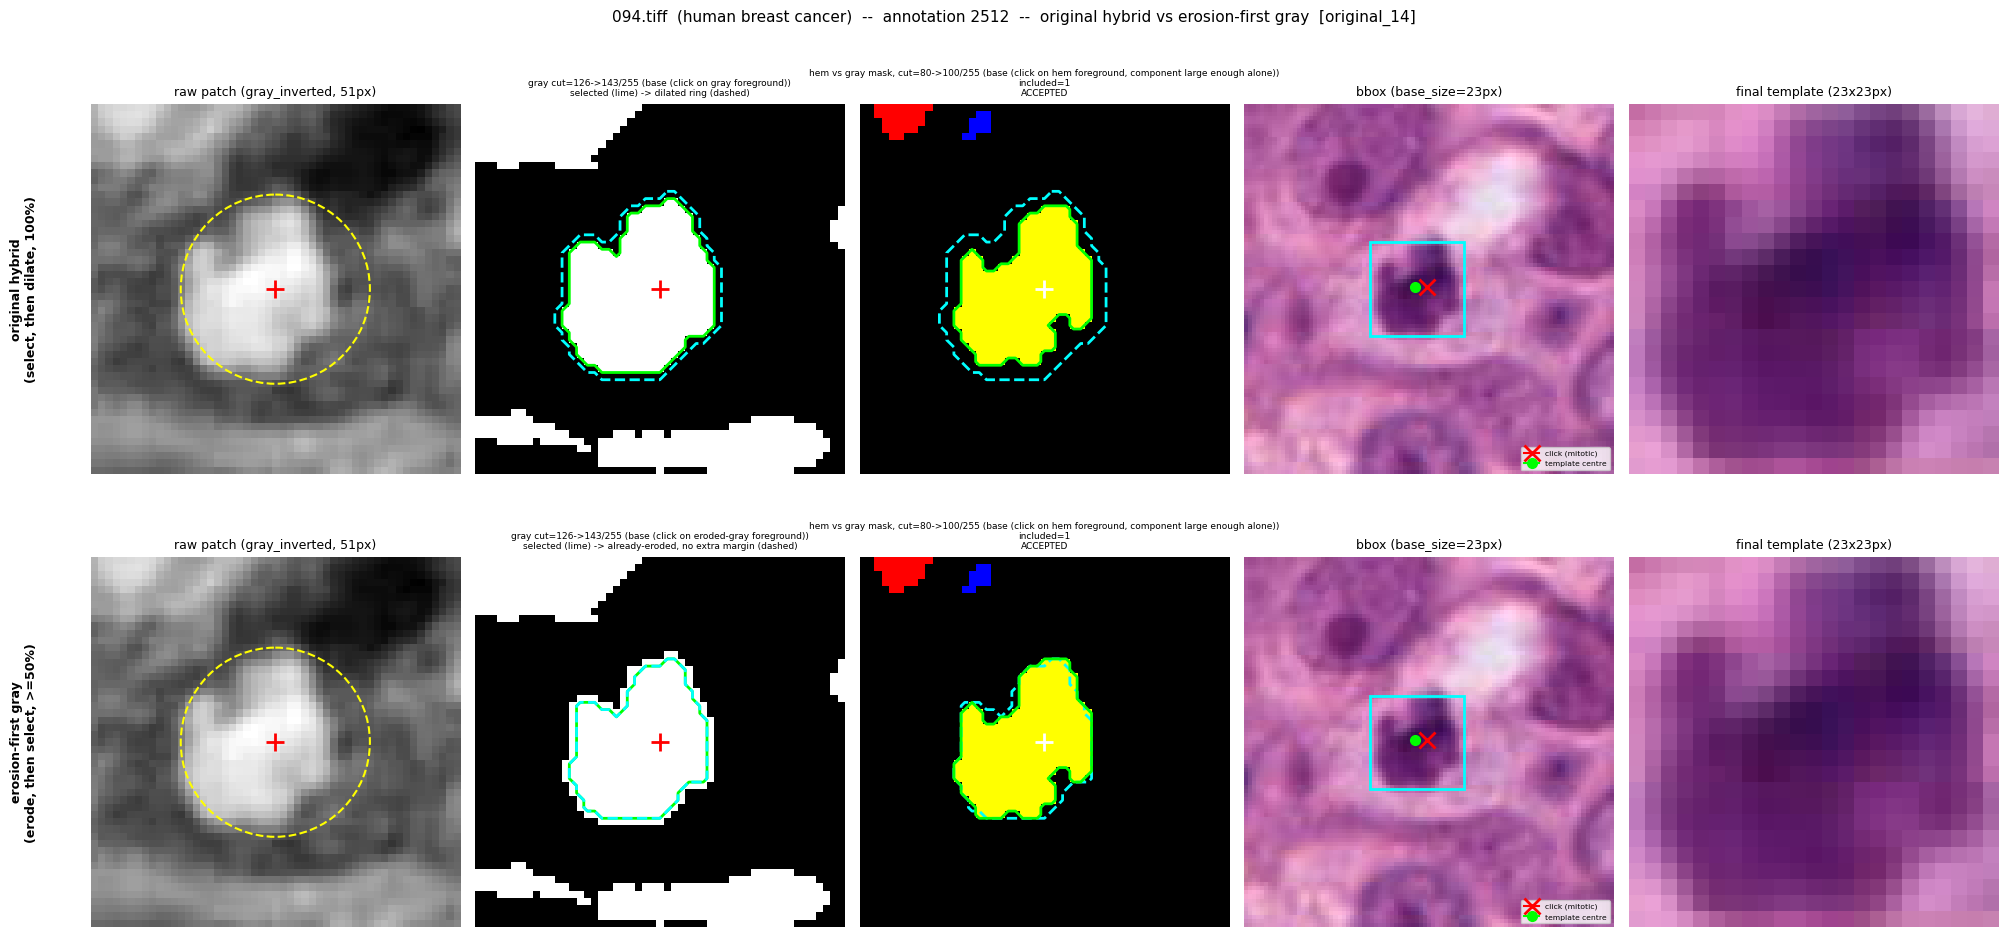

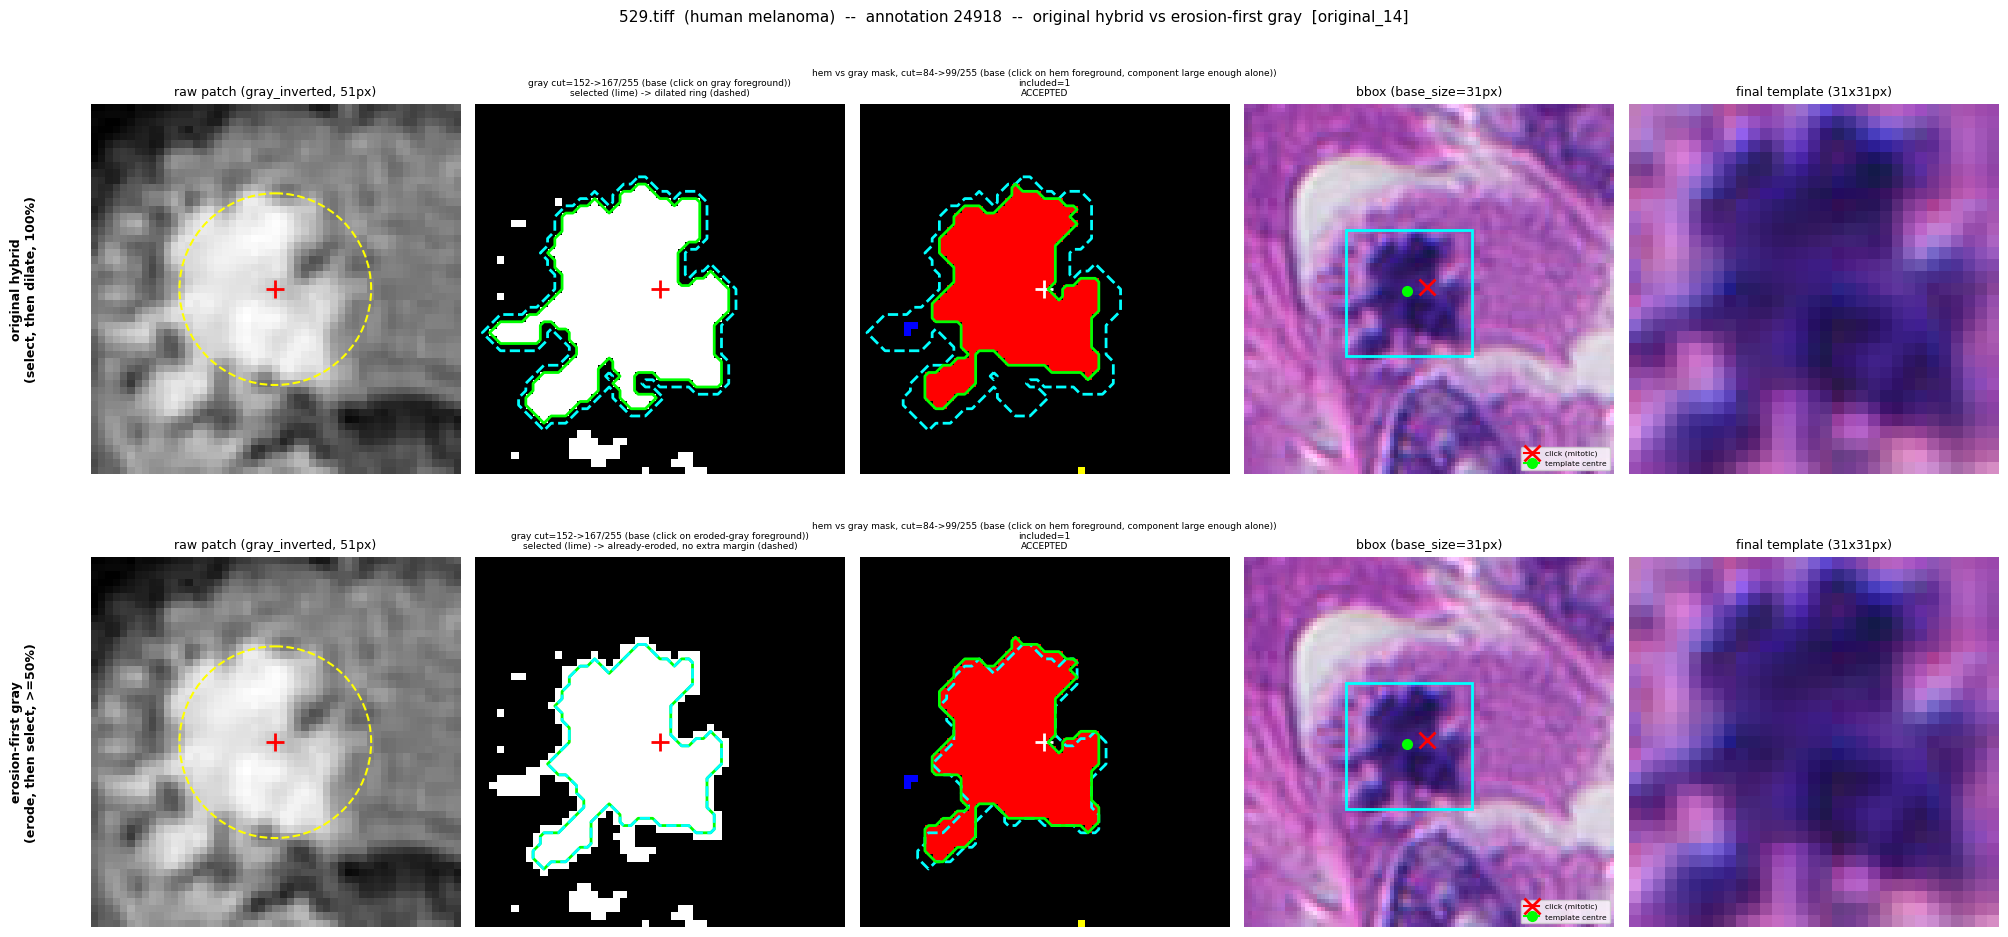

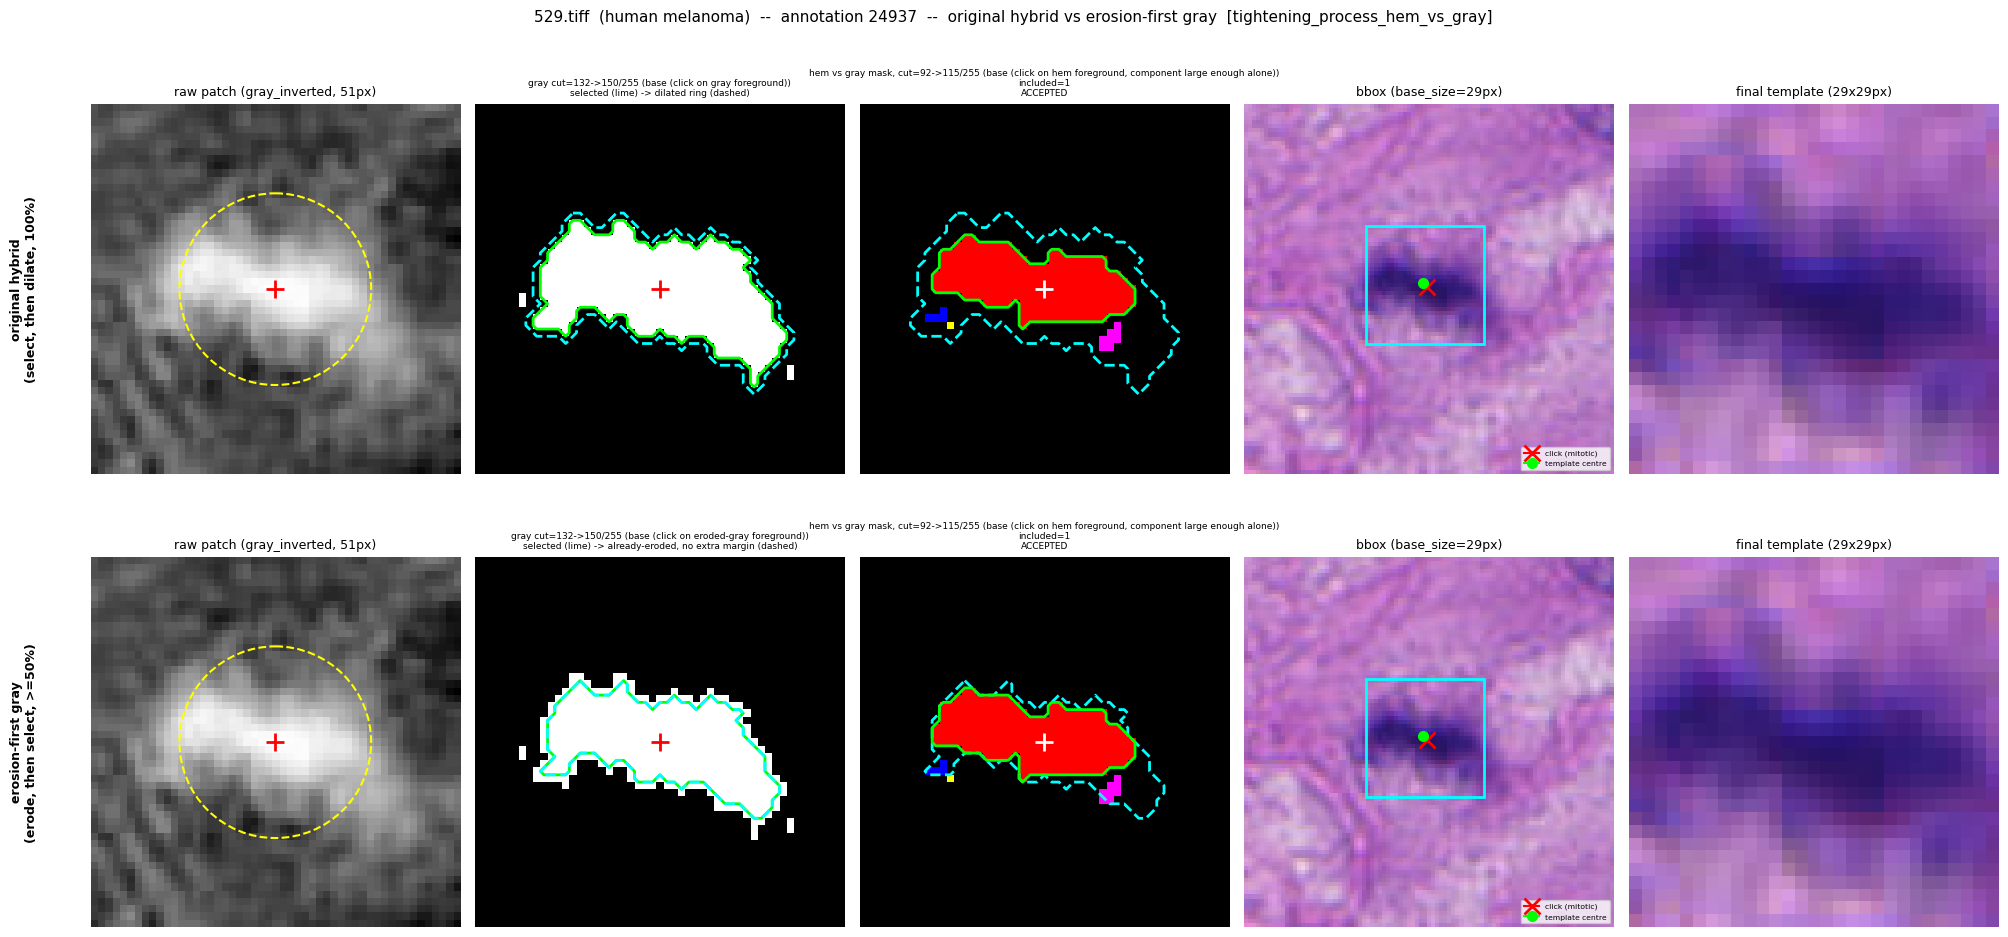

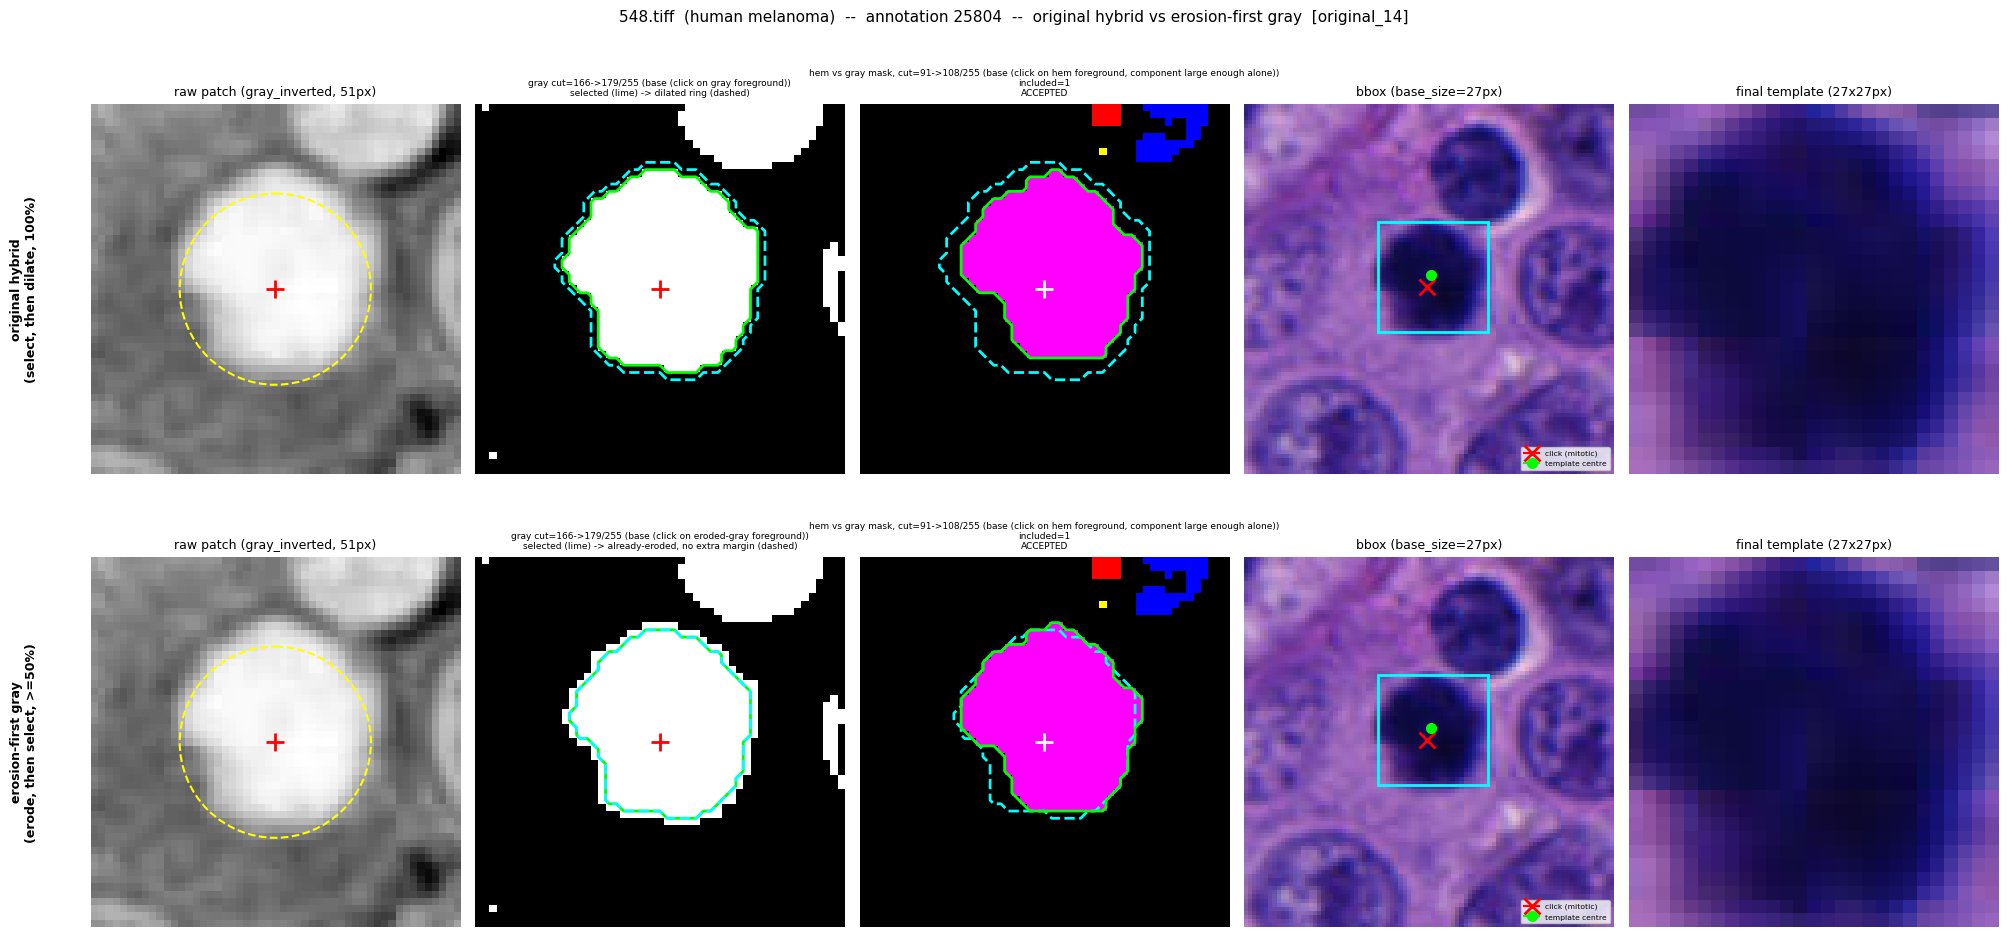

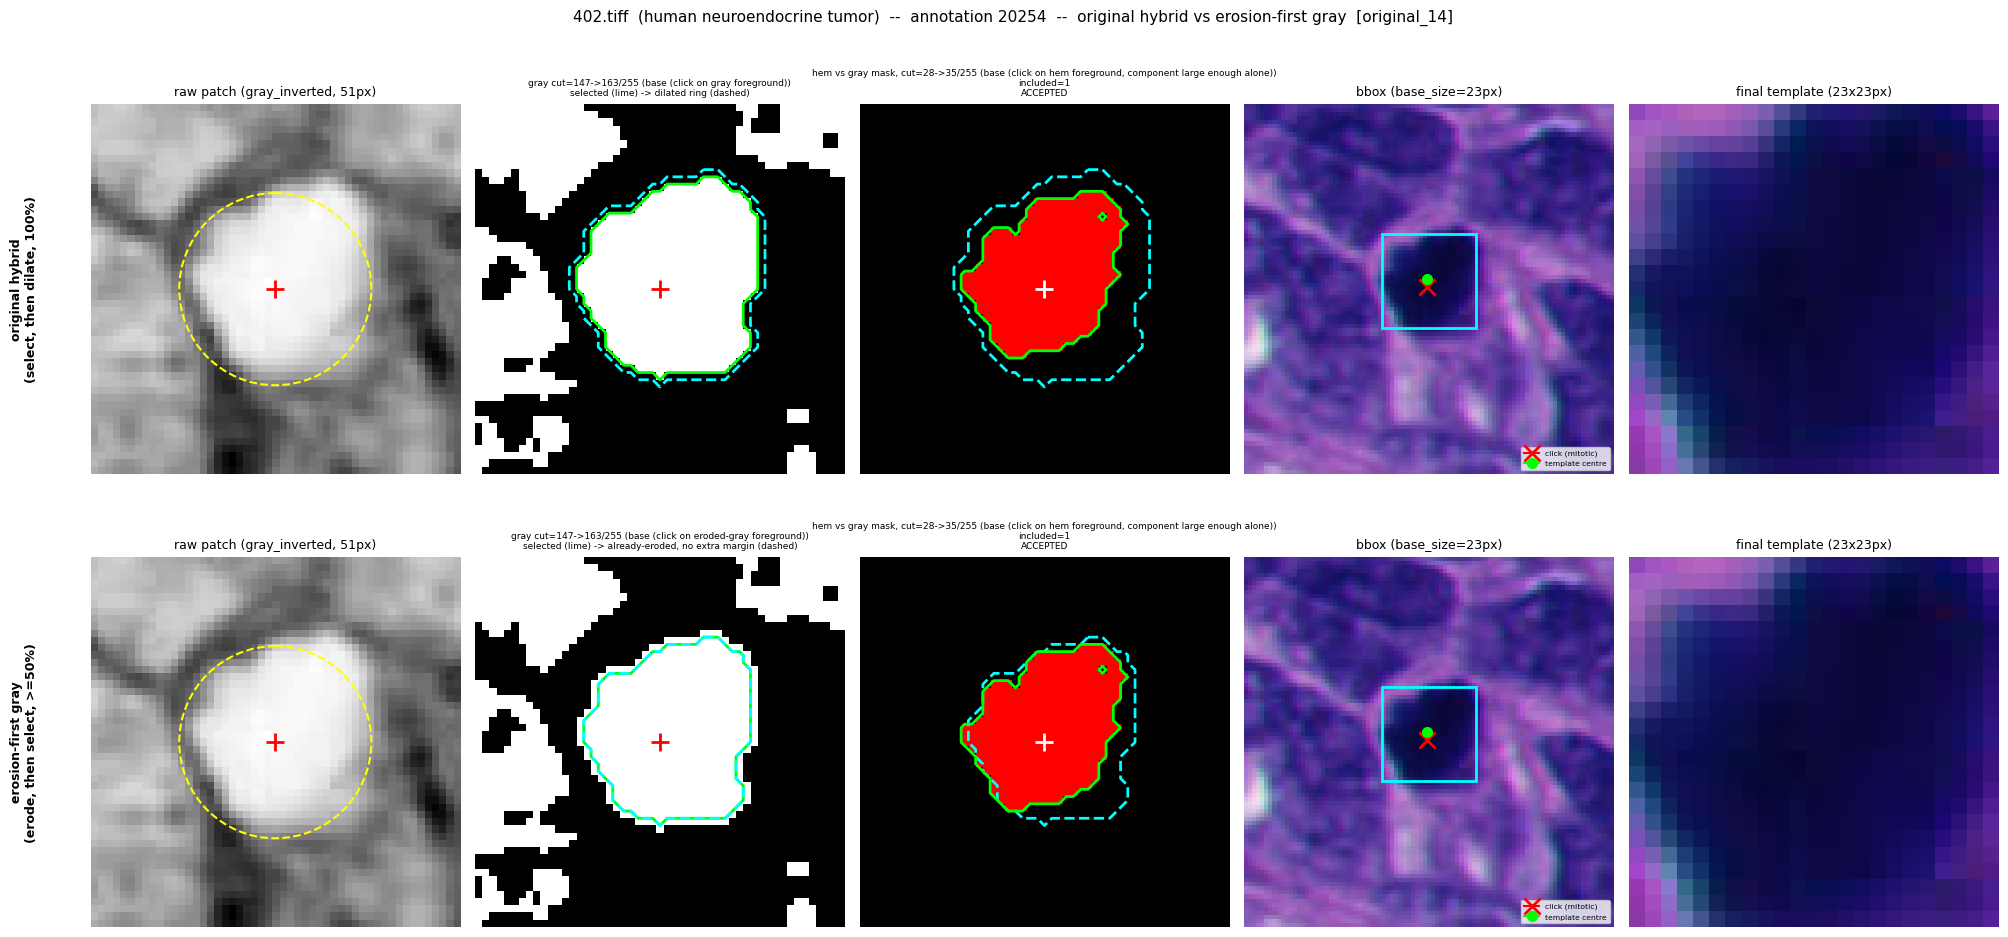

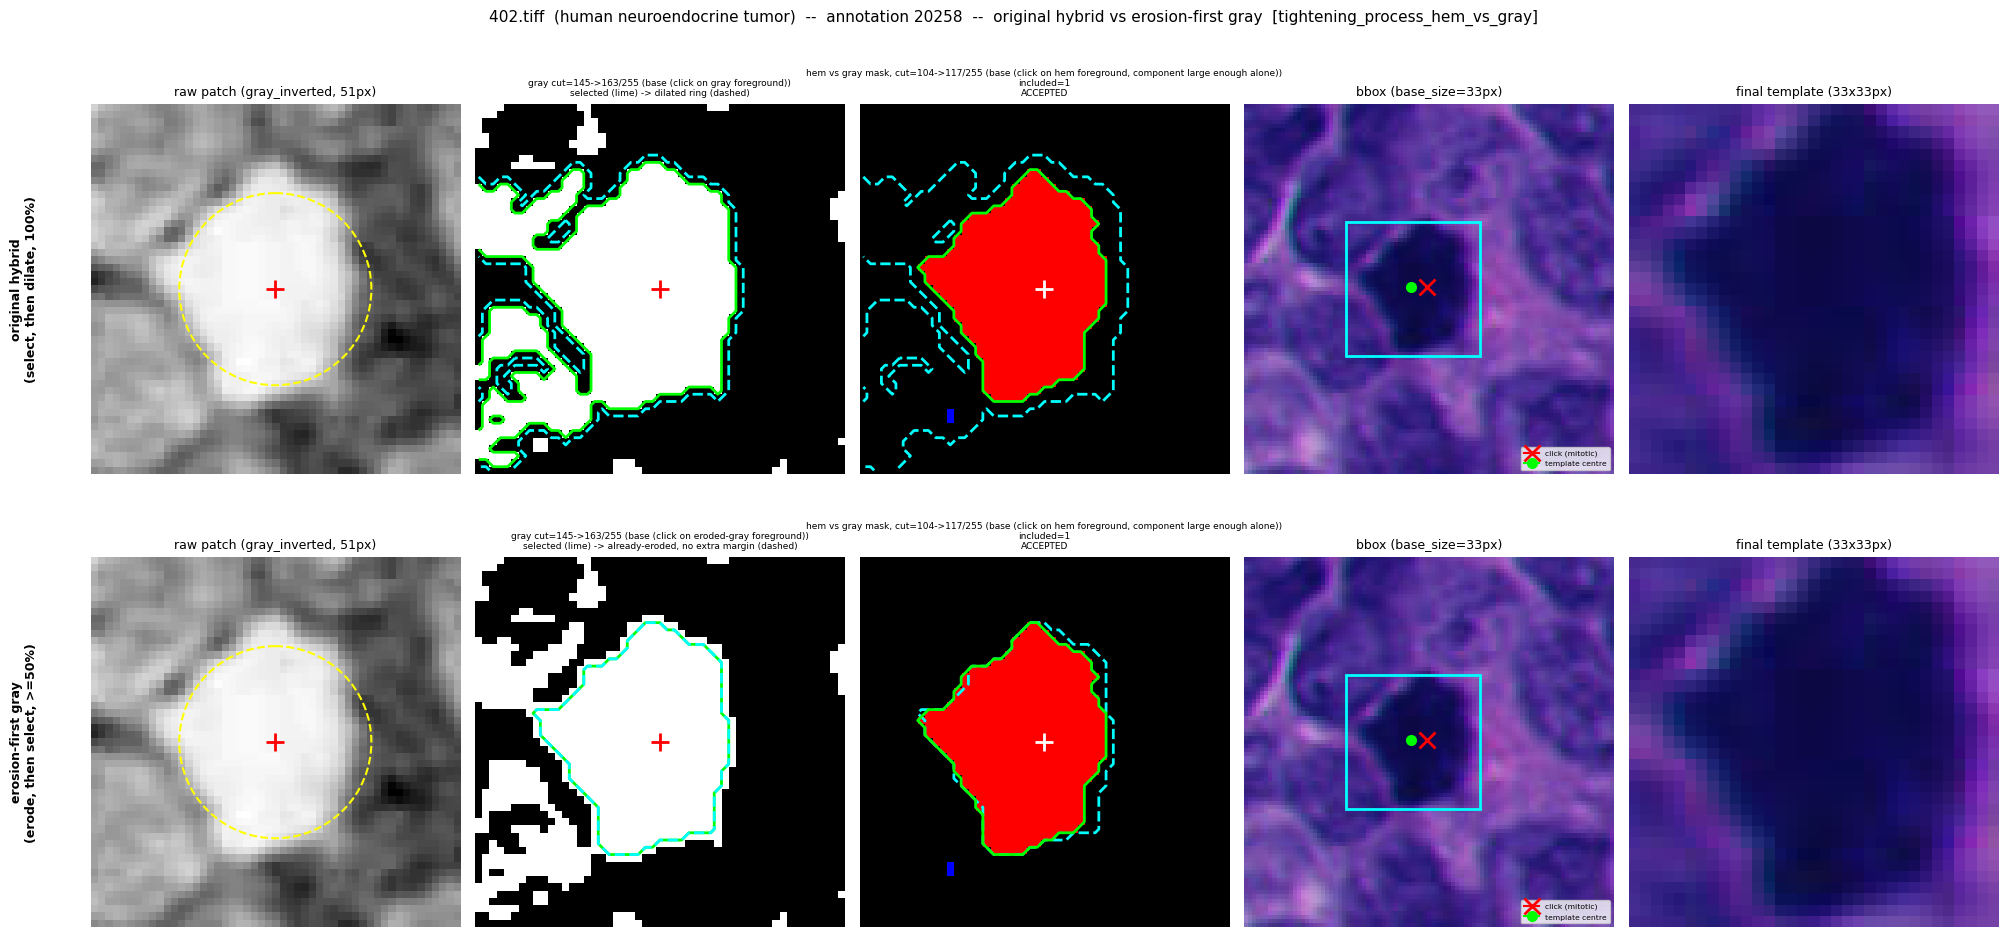

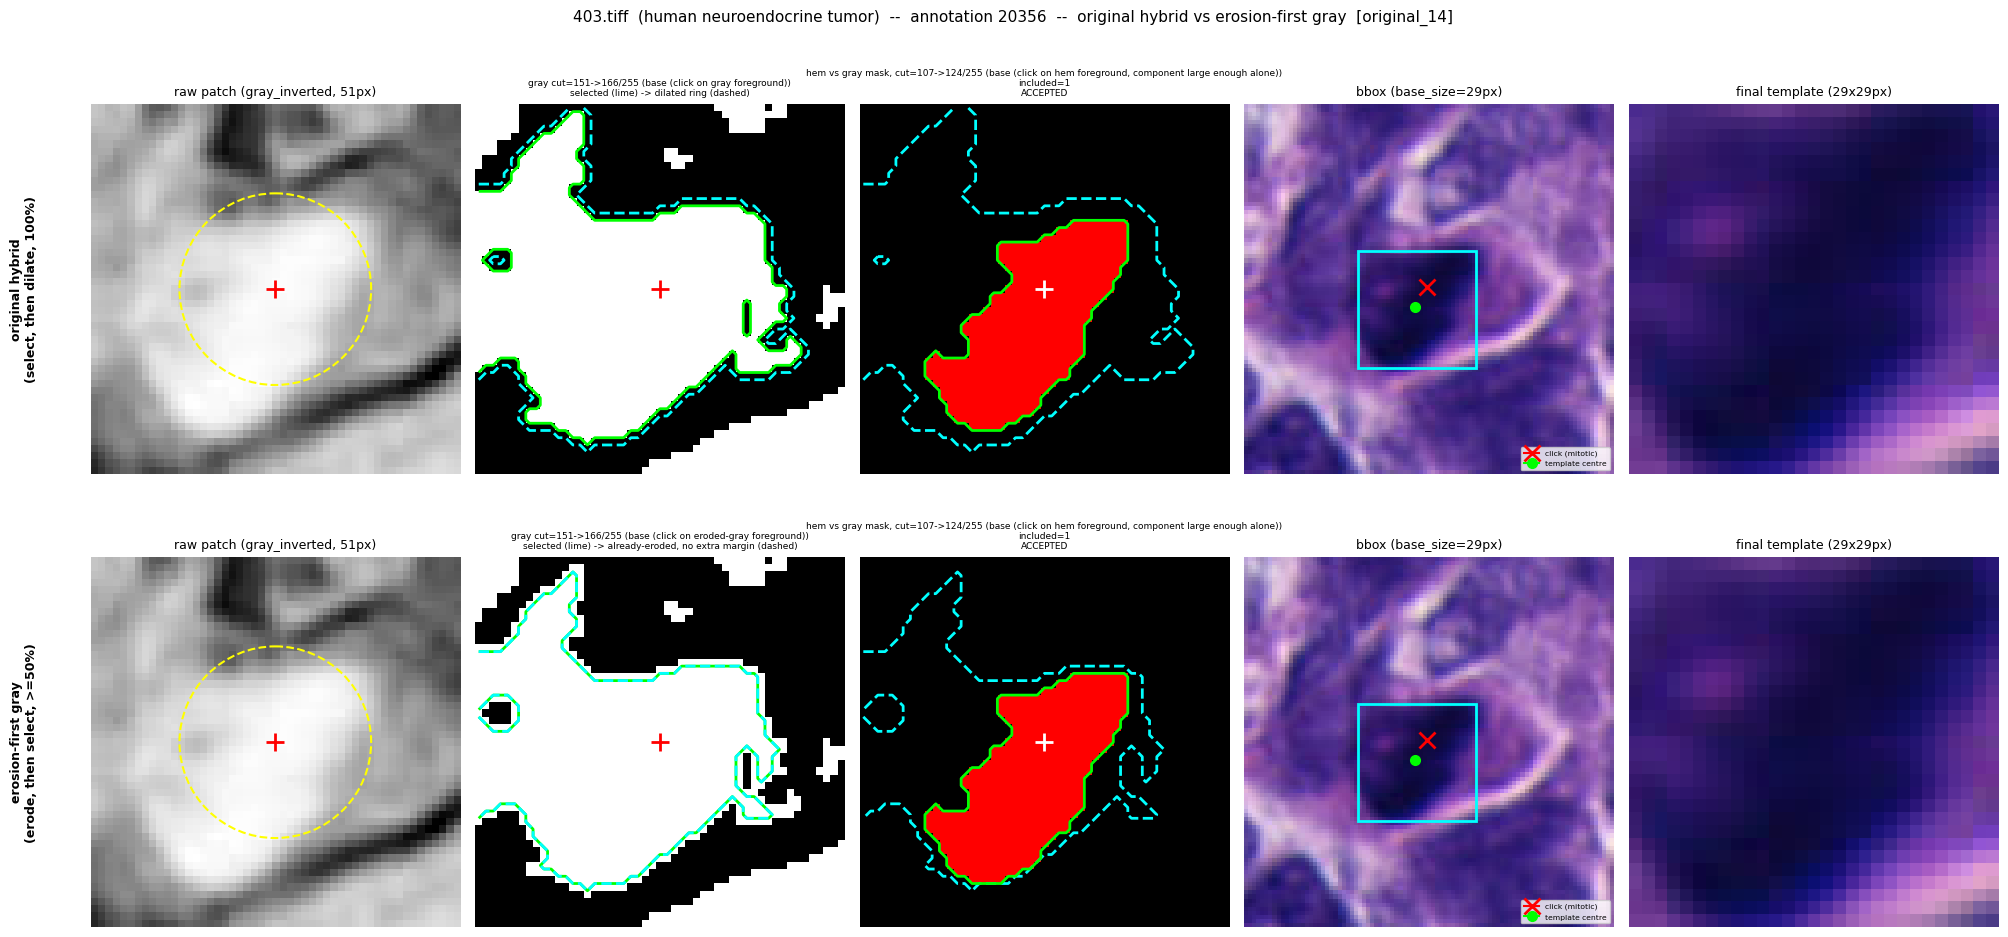

clicks where erosion-first diverges from the original hybrid: 1/24
[('245.tiff', 6243, True, (16, 44, 16, 47), True, (16, 34, 16, 28))]


In [7]:
SUMMARY_ORIGINAL, SUMMARY_ERODEFIRST, VERDICT_DIFFS = [], [], []


def row_summary(res):
    return dict(accepted=res['accepted'], base_size=res.get('base_size'),
               gray_mode=res.get('gray_mode'), n_included=len(res.get('included_hem_labels', [])),
               n_candidates=len(res.get('hem_candidates', [])),
               union_area=res.get('union_area'), reason=None if res['accepted'] else res['reason'])


order = sorted(CLICKS, key=lambda c: (c['domain'], c['file_name'], c['ann_id']))

for click in order:
    fn, ann_id, cx, cy, domain = click['file_name'], click['ann_id'], click['cx'], click['cy'], click['domain']
    arrs = CLICK_ARRAYS[fn]
    rgb, mpp, gray_inv, hem_chan = arrs['rgb'], arrs['mpp'], arrs['gray_inv'], arrs['hem_chan']

    res_original = explore_hybrid_tightening(gray_inv, hem_chan, cx, cy, mpp)
    res_erodefirst = explore_hybrid_tightening_erode_first(gray_inv, hem_chan, cx, cy, mpp)

    if res_original['accepted'] != res_erodefirst['accepted'] or (res_original['accepted']
            and (res_original['bbox'] != res_erodefirst['bbox'] or res_original['base_size'] != res_erodefirst['base_size'])):
        VERDICT_DIFFS.append((fn, ann_id, res_original['accepted'], res_original.get('bbox'),
                              res_erodefirst['accepted'], res_erodefirst.get('bbox')))

    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    gt_all = ds.image_annotations(annotations, fn)
    dx, dy = gt_all['cx'] - ix, gt_all['cy'] - iy
    nearby_gt = gt_all[(dx.abs() <= half_ctx) & (dy.abs() <= half_ctx) & (gt_all['ann_id'] != ann_id)]

    fig, axes = plt.subplots(2, 5, figsize=(20, 9.6))
    plot_hybrid_row(axes[0], 'original hybrid\n(select, then dilate, 100%)', 'dilated ring', res_original, rgb, cx, cy, nearby_gt)
    plot_hybrid_row(axes[1], 'erosion-first gray\n(erode, then select, >=50%)', 'already-eroded, no extra margin', res_erodefirst, rgb, cx, cy, nearby_gt)

    fig.suptitle(f'{fn}  ({domain})  --  annotation {ann_id}  --  original hybrid vs erosion-first gray  [{click["source"]}]',
                fontsize=11, y=1.01)
    fig.tight_layout(h_pad=3.0)
    fig.savefig(f'{OUT_PREFIX}_{fn.replace(".tiff","")}_{ann_id}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    SUMMARY_ORIGINAL.append(dict(source=click['source'], domain=domain, file_name=fn, ann_id=ann_id, **row_summary(res_original)))
    SUMMARY_ERODEFIRST.append(dict(source=click['source'], domain=domain, file_name=fn, ann_id=ann_id, **row_summary(res_erodefirst)))

print(f'clicks where erosion-first diverges from the original hybrid: {len(VERDICT_DIFFS)}/{len(order)}')
if VERDICT_DIFFS:
    print(VERDICT_DIFFS)

## Step 3 -- comparison table

In [8]:
SUMMARY_ORIGINAL_DF = pd.DataFrame(SUMMARY_ORIGINAL)
SUMMARY_ERODEFIRST_DF = pd.DataFrame(SUMMARY_ERODEFIRST)
SUMMARY_ORIGINAL_DF.to_csv(f'{OUT_PREFIX}_original_summary.csv', index=False)
SUMMARY_ERODEFIRST_DF.to_csv(f'{OUT_PREFIX}_erodefirst_summary.csv', index=False)

orig = SUMMARY_ORIGINAL_DF.set_index(['file_name', 'ann_id'])
ef = SUMMARY_ERODEFIRST_DF.set_index(['file_name', 'ann_id'])

COMPARISON = pd.DataFrame({
    'source': orig['source'], 'domain': orig['domain'],
    'accepted_original': orig['accepted'], 'accepted_erodefirst': ef['accepted'],
    'base_original': orig['base_size'], 'base_erodefirst': ef['base_size'],
    'base_size_delta': ef['base_size'] - orig['base_size'],
    'gray_mode_erodefirst': ef['gray_mode'],
    'n_included_original': orig['n_included'], 'n_included_erodefirst': ef['n_included'],
    'union_area_original': orig['union_area'], 'union_area_erodefirst': ef['union_area'],
    'reason_erodefirst': ef['reason'],
}).sort_values('base_original')
COMPARISON.to_csv(f'{OUT_PREFIX}_comparison.csv')

print(f'-> {OUT_PREFIX}_comparison.csv  ({len(COMPARISON)} rows)')
print(f"accepted: original {int(orig['accepted'].sum())}/{len(orig)}, erosion-first {int(ef['accepted'].sum())}/{len(ef)}")
print(f"base_size identical on {(COMPARISON['base_size_delta'] == 0).sum()}/{len(COMPARISON)} clicks (of those both accepted)")
COMPARISON

-> hybriderodefirst50vsoriginal14_comparison.csv  (24 rows)
accepted: original 24/24, erosion-first 24/24
base_size identical on 23/24 clicks (of those both accepted)


,,source,domain,accepted_original,accepted_erodefirst,base_original,base_erodefirst,base_size_delta,gray_mode_erodefirst,n_included_original,n_included_erodefirst,union_area_original,union_area_erodefirst,reason_erodefirst
file_name,ann_id,,,,,,,,,,,,,
245.tiff,6317,original_14,canine lymphosarcoma,True,True,21,21,0,base (click on eroded-gray foreground),1,1,216,216,None
300.tiff,14499,original_14,canine cutaneous mast cell tumor,True,True,23,23,0,base (click on eroded-gray foreground),1,1,215,215,None
402.tiff,20254,original_14,human neuroendocrine tumor,True,True,23,23,0,base (click on eroded-gray foreground),1,1,351,351,None
094.tiff,2512,original_14,human breast cancer,True,True,23,23,0,base (click on eroded-gray foreground),1,1,277,277,None
233.tiff,5761,original_14,canine lung cancer,True,True,23,23,0,base (click on eroded-gray foreground),1,1,354,354,None
246.tiff,6548,original_14,canine lymphosarcoma,True,True,25,25,0,base (click on eroded-gray foreground),1,1,224,224,None
548.tiff,25804,original_14,human melanoma,True,True,27,27,0,base (click on eroded-gray foreground),1,1,449,449,None
529.tiff,24937,tightening_process_hem_vs_gray,human melanoma,True,True,29,29,0,base (click on eroded-gray foreground),1,1,219,219,None
013.tiff,254,tightening_process_hem_vs_gray,human breast cancer,True,True,29,29,0,"fallback (click on eroded-gray background, uni...",1,1,455,455,None


## Closing notes

**Result: with the fallback reverted to a union (matching the original's own fallback style,
just on post-erosion components), 23 of 24 clicks now land on the identical box as the original
hybrid -- only 1 differs.** Still 24/24 accepted.

- **`013.tiff`/243** (the two-nuclei case) now matches the original exactly (41px box, 2 included
  components, confirmed via `gray_mode_erodefirst` = "union of 2 eroded components"). The
  nearest-only tie-break from the prior revision was what produced the tighter, single-nucleus
  17px box there -- switching the fallback back to a union removes that difference, as expected,
  since a union of both nearby eroded components reproduces the original's own union-of-both
  behaviour (evaluated on eroded rather than raw components, but landing on the same result here).
- **`245.tiff`/6243** (the fragmentation case) still differs -- 19px / 2 included components vs
  the original's 31px / 4. This is unaffected by the fallback change because this click never
  uses the fallback branch at all: the click lands directly on gray foreground (`gray_mode` =
  "base"), so it's the *erosion-first ordering itself* (not the fallback rule) that fixes it --
  the single eroded component the click resolves to no longer reaches the two hem components
  that previously rode in on the original's un-relabeled, effectively-fragmented gray selection.

**Take-away:** the fragmentation fix (erosion-first ordering) and the fallback rule (union vs.
nearest) are independent knobs, and this run isolates them cleanly -- the base-case fragmentation
fix persists regardless of the fallback choice (it only touches `245.tiff`/6243, a base-case
click), while the fallback choice only touches clicks that actually go through fallback
(`013.tiff`/243, the only one of the 24 that does with >1 candidate). With a union-style
fallback, this variant is now different from the original hybrid on exactly one click out of 24.

**Still true / not yet tested:**
- Sample size is 24 clicks; only 2 exercise either failure mode at all, and only 1 click in the
  whole sample has >1 gray fallback candidate -- there is no broader evidence here about which
  fallback rule (nearest vs. union) is better in general, only that they agree on every click in
  this sample except the one built to distinguish them.
- `GATE_KERNEL`/`GATE_ITERATIONS`, `CLICK_RADIUS_UM`, `HEM_MIN_BASE_SIZE_PX`, `DYNAMIC_K`, and
  `HEM_CONTAINMENT_FRAC` are all still first guesses, not tuned.
- Nothing here has been run through the actual pipeline (precision@K, NMS, matching) -- purely
  geometry, same scope as every notebook in this family so far.